# <b><span style='color:#0386f7de'>|</span> Fairness aware analysis and explainers <span style='color:#0386f7de'>|</span> </b>

*Authors: Naroa Iparraguirre and Urtats Berrocal*

# <b><span style='color:#0386f7de'>|</span> Statement of the exercise</b>

Assume that the information has been provided to you just in the middle of the pandemic. The data has to be
used with different aims:
1. There are very few resources such as hospital beds, medicine, etc. There are not resources for every
patient, and you need to decide with which patients you use them.
    - You know which patients have died and which ones survived (class)
    - The only sensible information you have about the patients is the sex and you want to ensure that
    there is not discrimination with regard to it.
2. The doctors want to learn which are the most important factors affecting the survival probability of the
patients and want tools to explain to individual patients what is affecting their probability of survival.


Develop a jupyter notebook or similar that includes the code and explanations (report and argue every decision
you have made and the obtained results). Use the libraries used in class as a tool to reach your objectives.
- Use the train/test, resampling strategies you consider adequate
- Select at least four classifiers to build the most trustful system to decide with which patients you
spend your resources. One of them should be an Artificial Neuronal Network model if you want
to reuse it for the second part.
- Perform a fairness analysis. Decide which is(are) the most important parity metric(s) and
argument the decision.
    - Try to mitigate bias
- Use global feature importance methods to find the most important biomarkers for death
prediction and local explanation methods to provide explanations and advice to individual
patients.
- Explain clearly each decision you made and the reached conclusions.


# <b>1<span style='color:#0386f7de'>|</span> Clinical Objective and Triage Policy</b>

Before analyzing the data, we must define how this model will be used in a real-world scarcity scenario. Our objective is to predict patient mortality to optimally allocate limited medical resources (e.g., ICU beds, ventilators) right at the emergency room door. 

**Triage Policy:**
In a mid-pandemic scenario with severe resource shortages, resources cannot be allocated based purely on "who is the sickest," as the highest-risk patients may unfortunately be futile cases. Therefore, our model will be used to identify patients in the **moderate-to-high risk threshold**. 
* Patients with low risk will be sent home to isolate.
* Patients with extreme risk (>85%) will be assigned palliative care.
* **Resources will be prioritized for the middle threshold**, where medical intervention has the highest probability of saving a life.

**The Ethical Metric Trade-Off:**
Because predicting "death" for a high-risk patient might mean denying them life-saving resources and sending them to palliative care, our model evaluation and fairness analysis must be highly sensitive to **False Positives** (predicting death for a patient who would have otherwise survived). While standard medicine usually favors high Recall (over-caution), in *this specific triage scenario*, poor Precision (too many false alarms) is fatal. We must balance capturing true risk without unfairly denying beds to survivors.

### The notebook includes:
1. Clinical Objective and Triage Policy
2. Importing libraries
3. Reading the dataset
4. Summary of numerical features
4. Data cleaning and feature selection
5. Data cleaning and feature selection
6. Some visualizations
7. Split dataset for training and testing
9. Fairness analysis
10. Mitigation
11. Global Explanations - Biomarkers
12. Local Explanations
13. Final Conclusion

# <b>2 <span style='color:#0386f7de'>|</span> Importing libraries</b>

In [1]:
# %pip install -r requirements.txt

In [2]:
import pandas as pd 
import numpy as np


%matplotlib inline
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.neighbors import KNeighborsClassifier
from sklearn import tree


from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.preprocessing import StandardScaler 
from sklearn import metrics
from sklearn.pipeline import Pipeline

#Resampling for imbalanced datasets 
from imblearn.under_sampling import RandomUnderSampler
from collections import Counter


# classifiers
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier

#Dalex library for checking fairness
import dalex as dx



# About The Dataset
#### This dataset contains anonymized Covid-19 patient-related information. The raw dataset consisted originally of 21 unique features and 1,048,576 unique patients. However, the dataset has been preprocessed to delete variables with too many missing values (2 variables) and keeping only patients with positive COVID-19 test (387.596).

The features included

* sex: female or male
* age: of the patient.
* classification: covid test findings. Values 1-3 mean covid in different degrees.
* patient type: hospitalized or not hospitalized.
* pneumonia: whether the patient already have air sacs inflammation or not.
* pregnancy: whether the patient is pregnant or not.
* diabetes: whether the patient has diabetes or not.
* copd: Indicates whether the patient has Chronic obstructive pulmonary disease or not.
* asthma: whether the patient has asthma or not.
* inmsupr: whether the patient is immunosuppressed or not.
* hypertension: whether the patient has hypertension or not.
* cardiovascular: whether the patient has heart or blood vessels related disease.
* renal chronic: whether the patient has chronic renal disease or not.
* other disease: whether the patient has other disease or not.
* obesity: whether the patient is obese or not.
* tobacco: whether the patient is a tobacco user.
* usmr: Indicates whether the patient treated medical units of the first, second or third level.
* medical unit: type of institution of the National Health System that provided the care.
* death: indicates whether the patient died or recovered.

All boolean variables have been transformed so that, 1 means "yes" and 0 means "no". Sex has been kept as categorical.

# <b>3 <span style='color:#0386f7de'>|</span> Reading the dataset</b>

In this section, our first step is to load the COVID-19 clinical dataset and examine its basic structure. We read the `.csv` file into a Pandas DataFrame to verify its dimensions and get an initial look at the features we will be working with. 

Crucially, we also need to evaluate the class distributions of key categorical variables (`SEX`, `CLASIFFICATION_FINAL`, `DEATH`, and `PREGNANT`). In biomedical data analysis, it is extremely common to encounter severe class imbalances—especially in clinical target variables like patient mortality. If a variable like `DEATH` is heavily skewed, standard machine learning models will naturally become biased toward predicting the majority class (survival) to artificially inflate accuracy. By identifying these imbalances right at the beginning of our EDA, we can properly justify the need for data balancing strategies later in our pipeline, ensuring our final classifiers are robust, clinically reliable, and unbiased.

In [3]:
#read data to a dataframe and visualize some rows to have an idea of how it looks like
df_C19 = pd.read_csv("Covid19.csv")
print("Shape of df :",df_C19.shape)
df_C19.head()

Shape of df : (387596, 20)


,Unnamed: 0,USMER,MEDICAL_UNIT,SEX,PATIENT_TYPE,PNEUMONIA,AGE,PREGNANT,DIABETES,COPD,ASTHMA,INMSUPR,HIPERTENSION,OTHER_DISEASE,CARDIOVASCULAR,OBESITY,RENAL_CHRONIC,TOBACCO,DEATH,CLASIFFICATION_FINAL
0,0,0,1,Female,1,1,65,0,0,0,0,0,1,0,0,0,0,0,1,3
1,2,0,1,Male,0,0,55,0,1,0,0,0,0,0,0,0,0,0,1,3
2,4,0,1,Male,1,0,68,0,1,0,0,0,1,0,0,0,0,0,1,3
3,5,0,1,Female,0,1,40,0,0,0,0,0,0,0,0,0,0,0,0,3
4,6,0,1,Female,1,0,64,0,0,0,0,0,0,0,0,0,0,0,0,3


In [4]:
#check number of SEX examples in the database and how bananced it is
df_C19.SEX.value_counts()


SEX
Male      207594
Female    180002
Name: count, dtype: int64

In [5]:
#check number of CLASIFFICATION_FINAL examples in the database and how bananced it is
df_C19.CLASIFFICATION_FINAL.value_counts()

CLASIFFICATION_FINAL
3    377378
1      8417
2      1801
Name: count, dtype: int64

In [6]:
#check number of DEATH examples in the database and how bananced it is
df_C19.DEATH.value_counts()

DEATH
0    334274
1     53322
Name: count, dtype: int64

In [7]:
#check number of PREGNANT examples in the database and how bananced it is
df_C19.PREGNANT.value_counts()

PREGNANT
0    384852
1      2744
Name: count, dtype: int64

**Note:** as it can be observed, the database is very imbalanced. Consequently, balanacing strategies will be convenient in the training process.

# <b>4 <span style='color:#0386f7de'>|</span> Summary Of Numerical Features</b>

In this section, we generate a descriptive statistical summary of our dataset. We transposed the output (`.T`) and applied a custom style to make the table easier to read for our report. 

Methodologically, this is a vital step in our Exploratory Data Analysis (EDA) to ensure data integrity. For continuous variables like `AGE`, this allows us to quickly verify plausible ranges (e.g., spotting minimums of 0 and maximums of 120) and understand the central tendency. Furthermore, because our clinical comorbidities (like `DIABETES`, `PNEUMONIA`, etc.) are encoded as binary variables (0 and 1), the `mean` column acts as a quick prevalence check. For example, looking at the mean of `DIABETES` (~0.158) instantly tells us that roughly 15.8% of the patients in our dataset have this condition. This summary confirms there are no obvious anomalous values (like negative numbers or extreme outliers) before we proceed to visualization and modeling.

In [8]:
df_C19.describe().T.style.set_properties(**{'background-color': 'grey','color': 'white','border-color': 'white'})

,count,mean,std,min,25%,50%,75%,max
Unnamed: 0,387596.000000,362488.215965,214640.115758,0.000000,119204.750000,448119.500000,546317.250000,1021520.000000
USMER,387596.000000,0.375889,0.484352,0.000000,0.000000,0.000000,1.000000,1.000000
MEDICAL_UNIT,387596.000000,8.677659,3.771074,0.000000,4.000000,12.000000,12.000000,13.000000
PATIENT_TYPE,387596.000000,0.717087,0.450415,0.000000,0.000000,1.000000,1.000000,1.000000
PNEUMONIA,387596.000000,0.218434,0.413184,0.000000,0.000000,0.000000,0.000000,1.000000
AGE,387596.000000,45.156570,16.458651,0.000000,33.000000,44.000000,56.000000,120.000000
PREGNANT,387596.000000,0.007080,0.083842,0.000000,0.000000,0.000000,0.000000,1.000000
DIABETES,387596.000000,0.158794,0.365485,0.000000,0.000000,0.000000,0.000000,1.000000
COPD,387596.000000,0.015655,0.124139,0.000000,0.000000,0.000000,0.000000,1.000000
ASTHMA,387596.000000,0.026618,0.160964,0.000000,0.000000,0.000000,0.000000,1.000000


# <b>5 <span style='color:#0386f7de'>|</span> Data Cleaning & Feature Selection</b>

In this section, we focus on cleaning and standardizing our dataset. Crucially, we must also prevent **Target Leakage**. 

Because our model is designed to be used for *triage* (when the patient first arrives at the hospital), it cannot use information that is generated *after* the triage decision is made. Features like `PATIENT_TYPE` (whether they were hospitalized), `MEDICAL_UNIT`, and `USMER` represent post-triage medical interventions. If we include them, we are "cheating" by giving the model future knowledge, rendering it useless for incoming patients. 


In [9]:
df_C19.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 387596 entries, 0 to 387595
Data columns (total 20 columns):
 #   Column                Non-Null Count   Dtype 
---  ------                --------------   ----- 
 0   Unnamed: 0            387596 non-null  int64 
 1   USMER                 387596 non-null  int64 
 2   MEDICAL_UNIT          387596 non-null  int64 
 3   SEX                   387596 non-null  object
 4   PATIENT_TYPE          387596 non-null  int64 
 5   PNEUMONIA             387596 non-null  int64 
 6   AGE                   387596 non-null  int64 
 7   PREGNANT              387596 non-null  int64 
 8   DIABETES              387596 non-null  int64 
 9   COPD                  387596 non-null  int64 
 10  ASTHMA                387596 non-null  int64 
 11  INMSUPR               387596 non-null  int64 
 12  HIPERTENSION          387596 non-null  int64 
 13  OTHER_DISEASE         387596 non-null  int64 
 14  CARDIOVASCULAR        387596 non-null  int64 
 15  OBESITY          

The output shows that we have 387,596 entries with 20 columns. However, we need to drop unnecesary columns.

In [10]:
# Drop the index AND the leaky variables that occur after triage
columns_to_drop = ["Unnamed: 0", "PATIENT_TYPE", "MEDICAL_UNIT", "USMER"]
df_C19 = df_C19.drop(columns_to_drop, axis=1)
df_C19.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 387596 entries, 0 to 387595
Data columns (total 16 columns):
 #   Column                Non-Null Count   Dtype 
---  ------                --------------   ----- 
 0   SEX                   387596 non-null  object
 1   PNEUMONIA             387596 non-null  int64 
 2   AGE                   387596 non-null  int64 
 3   PREGNANT              387596 non-null  int64 
 4   DIABETES              387596 non-null  int64 
 5   COPD                  387596 non-null  int64 
 6   ASTHMA                387596 non-null  int64 
 7   INMSUPR               387596 non-null  int64 
 8   HIPERTENSION          387596 non-null  int64 
 9   OTHER_DISEASE         387596 non-null  int64 
 10  CARDIOVASCULAR        387596 non-null  int64 
 11  OBESITY               387596 non-null  int64 
 12  RENAL_CHRONIC         387596 non-null  int64 
 13  TOBACCO               387596 non-null  int64 
 14  DEATH                 387596 non-null  int64 
 15  CLASIFFICATION_FI

Now, the output shows that we have 387,596 entries with 16 columns. There are no null values. We have 15 numeric features and 1 categorical feature (`SEX`). We can convert the `SEX` string attributes, which have only two unique values, into a numerical format.

In [11]:
df_C19 =  df_C19[df_C19.columns].replace({'Female':1, 'Male':0 })
df_C19['SEX'] = df_C19['SEX'].astype(int)
df_C19.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 387596 entries, 0 to 387595
Data columns (total 16 columns):
 #   Column                Non-Null Count   Dtype
---  ------                --------------   -----
 0   SEX                   387596 non-null  int32
 1   PNEUMONIA             387596 non-null  int64
 2   AGE                   387596 non-null  int64
 3   PREGNANT              387596 non-null  int64
 4   DIABETES              387596 non-null  int64
 5   COPD                  387596 non-null  int64
 6   ASTHMA                387596 non-null  int64
 7   INMSUPR               387596 non-null  int64
 8   HIPERTENSION          387596 non-null  int64
 9   OTHER_DISEASE         387596 non-null  int64
 10  CARDIOVASCULAR        387596 non-null  int64
 11  OBESITY               387596 non-null  int64
 12  RENAL_CHRONIC         387596 non-null  int64
 13  TOBACCO               387596 non-null  int64
 14  DEATH                 387596 non-null  int64
 15  CLASIFFICATION_FINAL  387596 non-n

Lastly, let's check that there are no abnormal values by observing the unique values per column.

In [12]:
df_C19.nunique()

SEX                       2
PNEUMONIA                 2
AGE                     108
PREGNANT                  2
DIABETES                  2
COPD                      2
ASTHMA                    2
INMSUPR                   2
HIPERTENSION              2
OTHER_DISEASE             2
CARDIOVASCULAR            2
OBESITY                   2
RENAL_CHRONIC             2
TOBACCO                   2
DEATH                     2
CLASIFFICATION_FINAL      3
dtype: int64

We can see that we have some attributes (like `AGE` or `CLASIFFICATION_FINAL`) that have more than two unique values. To handle these properly without implying a false mathematical hierarchy, we will use <span style='color:#0386f7de'>OneHotEncoder</span> in the preprocessing step later.

# <b>6 <span style='color:#0386f7de'>|</span> Some visualizations</b>

In this section, we want to visually explore our data to better understand the relationships between our clinical features and our target variable, `DEATH`. 

First, we will plot the overall distribution of mortality. We noted this numerically in the reading step, but visualizing it makes the severity of the class imbalance immediately apparent. Visually confirming this imbalance is crucial because it fundamentally shapes our modeling strategy: training a classifier on this raw distribution would yield an inadequate model biased toward predicting survival.

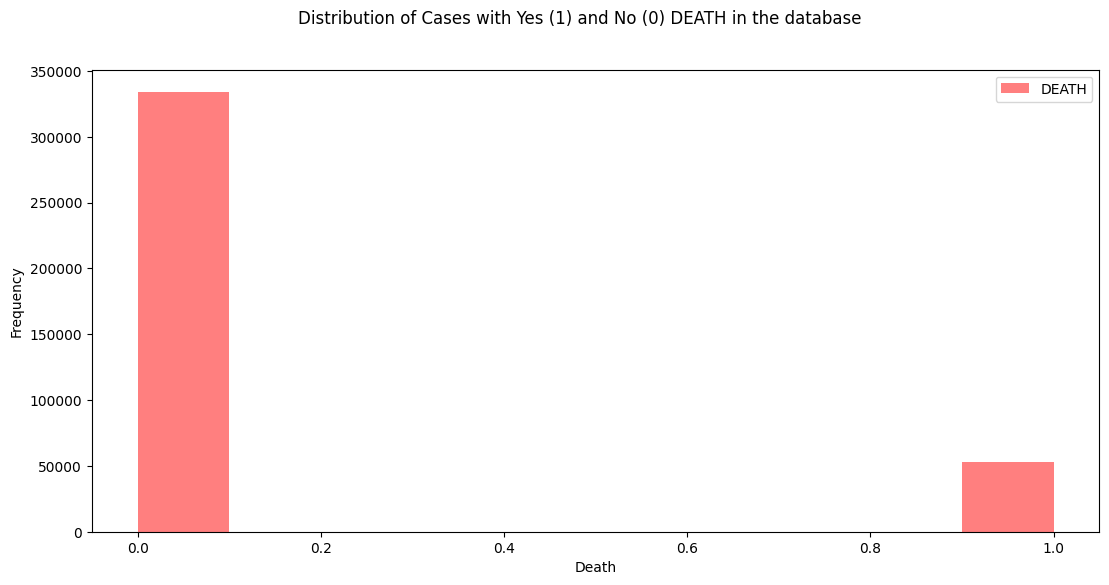

In [13]:
# death: indicates whether the patient died or recovered
# 1 means "yes" and 0 means "no"

fig, ax = plt.subplots(figsize = (13,6))

ax.hist(df_C19["DEATH"], alpha=0.5, color="red", label="DEATH")

ax.set_xlabel("Death")
ax.set_ylabel("Frequency")

fig.suptitle("Distribution of Cases with Yes (1) and No (0) DEATH in the database")

ax.legend();

As we can see from the plot, the database is highly imbalanced. We do not consider this distribution adequate for direct machine learning without applying balancing techniques later.

Next, we want to investigate if a patient's biological sex is a significant determining factor for COVID-19 mortality in our dataset. By plotting overlapping distributions of patients who died versus those who survived, categorized by `SEX`, we can visually compare the proportions.

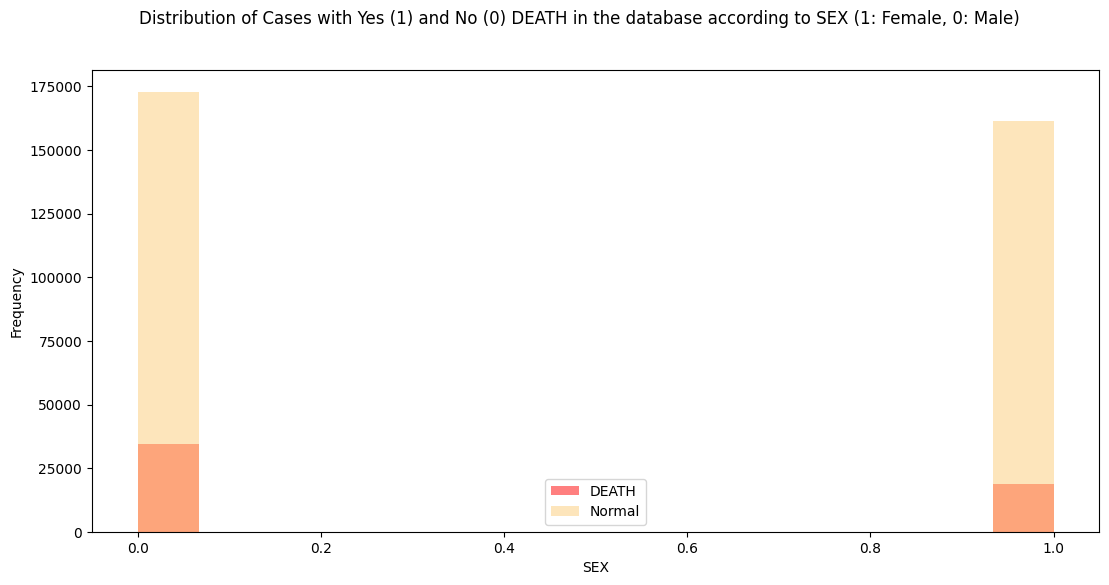

In [14]:
# Let's analyse if SEX seems to be determinant for death by covid.

fig, ax = plt.subplots(figsize = (13,6))

ax.hist(df_C19[df_C19["DEATH"]==1]["SEX"], bins=15, alpha=0.5, color="red", label="DEATH")
ax.hist(df_C19[df_C19["DEATH"]==0]["SEX"], bins=15, alpha=0.5, color="#fccc79", label="Normal")

ax.set_xlabel("SEX")
ax.set_ylabel("Frequency")

fig.suptitle("Distribution of Cases with Yes (1) and No (0) DEATH in the database according to SEX (1: Female, 0: Male)")

ax.legend();

Looking at the distributions, the ratio of deaths to survivals appears relatively similar across both sexes. Based on this visual inspection alone, we would not conclude that sex heavily affects the likelihood of death by COVID-19 in this specific cohort.

Finally, let's analyze `CLASIFFICATION_FINAL`. This feature represents the clinical COVID-19 test findings, where values 1-3 indicate varying degrees of confirmed COVID-19 infection. Overlapping the survival and mortality distributions here will help us see if a higher certainty/degree of COVID-19 diagnosis correlates with mortality.

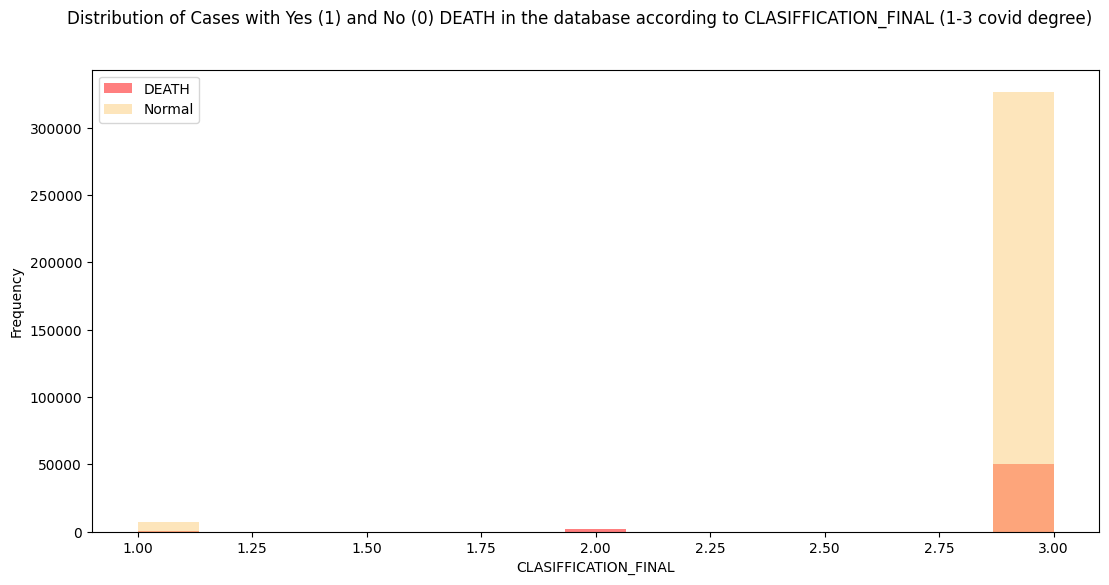

In [15]:
# classification: covid test findings. Values 1-3 mean covid in different degrees.
# Let's analyse if CLASIFFICATION_FINAL seems to be determinant for death by covid.

fig, ax = plt.subplots(figsize = (13,6))

ax.hist(df_C19[df_C19["DEATH"]==1]["CLASIFFICATION_FINAL"], bins=15, alpha=0.5, color="red", label="DEATH")
ax.hist(df_C19[df_C19["DEATH"]==0]["CLASIFFICATION_FINAL"], bins=15, alpha=0.5, color="#fccc79", label="Normal")

ax.set_xlabel("CLASIFFICATION_FINAL")
ax.set_ylabel("Frequency")

fig.suptitle("Distribution of Cases with Yes (1) and No (0) DEATH in the database according to CLASIFFICATION_FINAL (1-3 covid degree)")

ax.legend();

In this case, looking at the distributions, the ratio of death to survival changes noticeably depending on the test finding classification. We can reasonably deduce that the COVID-19 diagnosis degree heavily influences mortality, highlighting this feature as a potentially strong predictor for our models.

# <b>7 <span style='color:#0386f7de'>|</span> Split Dataset for Training and Testing</b>

In this section, we prepare our data for the modeling phase by splitting it into training and testing sets using a standard 70/30 holdout method. We will also incorporate cross-validation later during the training process to ensure robustness.

Recall from our previous visualizations that our target variable (`DEATH`) is severely imbalanced. If we train our models on this raw distribution, they will naturally become biased toward the majority class (survival) to artificially maximize accuracy. To correct this, we implement **Random Undersampling** to balance the classes. 

**Methodological Justification:** It is critical that we only apply this undersampling to the **training data**. The testing data must deliberately be left untouched to retain its original, imbalanced distribution. We train the model on an artificially balanced environment so it can learn the clinical patterns of mortality equally well, but we must test it on a mathematically realistic distribution to evaluate how it will actually perform in a real-world hospital setting.

In [16]:
#train/test split. 
X_train, X_test, y_train, y_test = train_test_split(df_C19.drop("DEATH", axis =1),
                                                    df_C19.DEATH,
                                                    test_size=0.3,
                                                    random_state=123)

print('Shape of training feature:', X_train.shape)
print('Shape of testing feature:', X_test.shape)
print('Shape of training label:', y_train.shape)
print('Shape of training label:', y_test.shape)
print(f"Training target statistics: {Counter(y_train)}")



Shape of training feature: (271317, 15)
Shape of testing feature: (116279, 15)
Shape of training label: (271317,)
Shape of training label: (116279,)
Training target statistics: Counter({0: 234164, 1: 37153})


We will now **undersample the training sample** to obtain a uniformly balanced database for our algorithms to learn from.

In [17]:
# Resample training sample. Undersample it to obtain a balanced sample
under_sampler = RandomUnderSampler(random_state=42)
X_train, y_train = under_sampler.fit_resample(X_train, y_train)

print(f"Training target statistics after resampling: {Counter(y_train)}")
print(f"Testing target statistics (unchanged): {Counter(y_test)}")

Training target statistics after resampling: Counter({0: 37153, 1: 37153})
Testing target statistics (unchanged): Counter({0: 100110, 1: 16169})


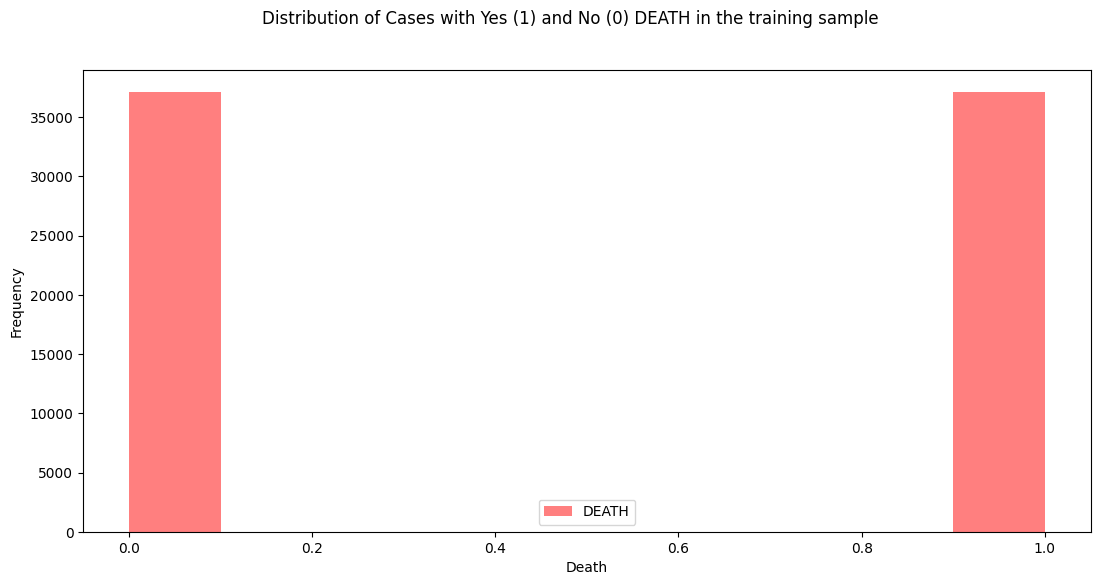

In [18]:
# Visualize the new balanced Training Set
# death: indicates whether the patient died or recovered
# 1 means "yes" and 0 means "no"

fig, ax = plt.subplots(figsize=(13,6))

ax.hist(y_train, alpha=0.5, color="red", label="DEATH")
ax.set_xlabel("Death")
ax.set_ylabel("Frequency")
fig.suptitle("Distribution of Cases with Yes (1) and No (0) DEATH in the training sample")
ax.legend();

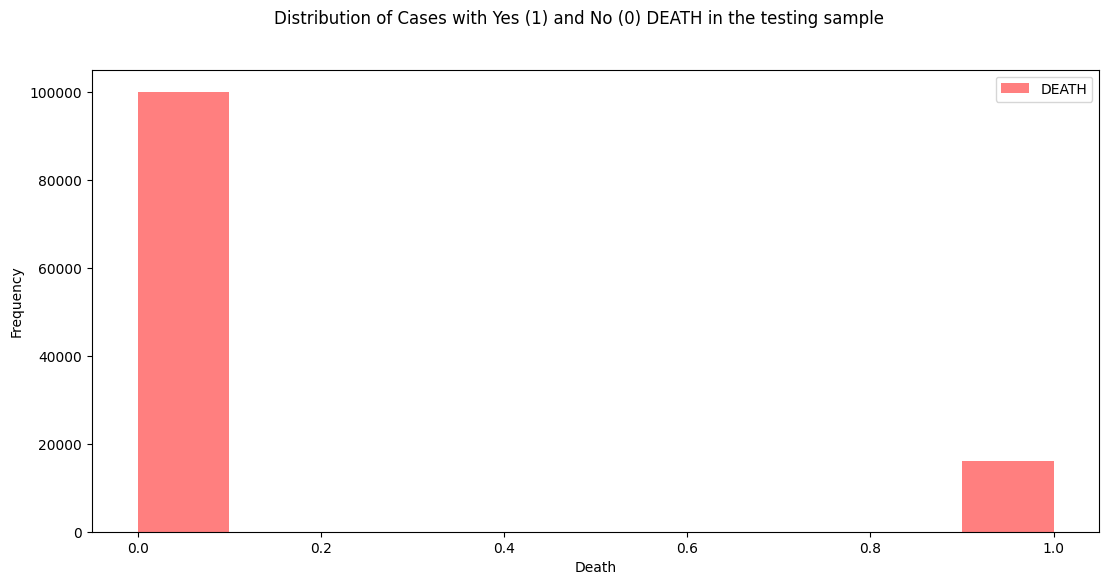

In [19]:
# Visualize the unchanged Testing Set
# death: indicates whether the patient died or recovered
# 1 means "yes" and 0 means "no"

fig, ax = plt.subplots(figsize=(13,6))

ax.hist(y_test, alpha=0.5, color="red", label="DEATH")
ax.set_xlabel("Death")
ax.set_ylabel("Frequency")
fig.suptitle("Distribution of Cases with Yes (1) and No (0) DEATH in the testing sample")
ax.legend();

**Note:** At this moment, we have a perfectly balanced training sample for unbiased learning, but as desired, the test set keeps the original distribution (the distribution we would most likely find in society and clinical practice).

# <b>8 <span style='color:#0386f7de'>|</span> Data Preprocessing and training</b>

Now that our training data is balanced, we transition to the core machine learning phase. 

We must apply different preprocessing steps depending on the data type:
1. **Continuous Variables (`AGE`):** We apply **Feature Standardization** (`StandardScaler`). Algorithms that rely on distance metrics (KNN) or gradient descent (MLP, Logistic Regression) are highly sensitive to raw scale.
2. **Categorical Variables (`CLASIFFICATION_FINAL`, etc.):** We apply **One-Hot Encoding** (`OneHotEncoder`). Because `CLASIFFICATION_FINAL` has values 1-3, passing it as a raw number would falsely tell the model that category 3 is mathematically "three times greater" than category 1. 

We bundle these transformations together with our classifiers using Scikit-Learn **ColumnTransformers** and **Pipelines** to prevent data leakage during training.

In [20]:
df_C19.columns

Index(['SEX', 'PNEUMONIA', 'AGE', 'PREGNANT', 'DIABETES', 'COPD', 'ASTHMA',
       'INMSUPR', 'HIPERTENSION', 'OTHER_DISEASE', 'CARDIOVASCULAR', 'OBESITY',
       'RENAL_CHRONIC', 'TOBACCO', 'DEATH', 'CLASIFFICATION_FINAL'],
      dtype='object')

In [21]:
# Separate features by type to apply correct preprocessing
categorical_features = ['SEX', 'PNEUMONIA', 'PREGNANT', 'DIABETES', 'COPD', 
                        'ASTHMA', 'INMSUPR', 'HIPERTENSION', 'OTHER_DISEASE', 
                        'CARDIOVASCULAR', 'OBESITY', 'RENAL_CHRONIC', 'TOBACCO', 
                        'CLASIFFICATION_FINAL']
numerical_features = ['AGE']

# Build the transformers
numerical_transformer = Pipeline(steps=[
    ('scale', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

# Combine into a preprocessor
preprocessor = ColumnTransformer(transformers=[
    ('num', numerical_transformer, numerical_features),
    ('cat', categorical_transformer, categorical_features)
])

In [22]:
clf_tree = Pipeline(steps=[('preprocessor', preprocessor), ('classifier', DecisionTreeClassifier(max_depth=10, random_state=123))])
clf_tree.fit(X_train, y_train)

clf_forest = Pipeline(steps=[('preprocessor', preprocessor), ('classifier', RandomForestClassifier(n_estimators=200, max_depth=10, random_state=123))])
clf_forest.fit(X_train, y_train)

clf_logreg = Pipeline(steps=[('preprocessor', preprocessor), ('classifier', LogisticRegression(max_iter=1000))])
clf_logreg.fit(X_train, y_train)

clf_knn = Pipeline(steps=[('preprocessor', preprocessor), ('classifier', KNeighborsClassifier(n_neighbors=5))])
clf_knn.fit(X_train, y_train)

clf_mlp = Pipeline(steps=[('preprocessor', preprocessor), ('classifier', MLPClassifier(hidden_layer_sizes=(64, 32), activation='relu', solver='adam', max_iter=500, random_state=123))])
clf_mlp.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('scale',
                                                                   StandardScaler())]),
                                                  ['AGE']),
                                                 ('cat',
                                                  Pipeline(steps=[('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['SEX', 'PNEUMONIA',
                                                   'PREGNANT', 'DIABETES',
                                                   'COPD', 'ASTHMA', 'INMSUPR',
                                                   'HIPERTENSION',
                                                   'OTHER_DISEASE',
                                                   'CARDIOVASCULAR', 'OBESITY',
                                                   'RENAL_CHRONIC', 'TOBACCO',
                                                   'CLASIFFICATION_FINAL'])])),
                ('classifier',
                 MLPClassifier(hidden_layer_sizes=(64, 32), max_iter=500,
                               random_state=123))])

# <b>9 <span style='color:#0386f7de'>|</span> Fairness analysis</b>

In order to compare potential mistreatment across different subgroups, we will use **Dalex Explainers**. In addition to generating model explanations, they give us the opportunity to deeply analyze model performance and biases.

## **Fairness Analysis: Selecting the Right Metric**
The prompt requires us to ensure there is no discrimination regarding `SEX`. However, to choose the correct parity metric, we must tie the math back to our **Triage Policy**.

If our policy dictates that hospital resources are denied to patients with an extreme probability of death, then a **False Positive** (predicting death for a patient who would have actually survived) is a fatal error. It means the model has unfairly denied a hospital bed to someone who could have lived.

Therefore, the most critical fairness metric for this scenario is **Predictive Equality (Equal False Positive Rates)**. If the False Positive Rate is higher for men than for women, it means our algorithm is systemically and unfairly sentencing men to death by denying them resources. We will prioritize balancing the FPR across both sexes.

In [23]:
#explainer for decision tree
exp_tree = dx.Explainer(clf_tree, X_test, y_test, verbose=False)

#explainer for random forest
exp_forest = dx.Explainer(clf_forest, X_test, y_test, verbose=False)

#explainer for logistic regression
exp_logreg = dx.Explainer(clf_logreg, X_test, y_test, verbose=False)

#explainer for knn
exp_knn = dx.Explainer(clf_knn, X_test, y_test, verbose=False)

#explainer for mlp
exp_mlp = dx.Explainer(clf_mlp, X_test, y_test, verbose=False)

## **9.1 Performance analysis**
The dalex explainer includes facilities to directly analyze model performance across our test set.

In [24]:
#concatenate the model performace of the four explainers generated exp_tree, exp_forest, exp_logreg, exp_knn and exp_mlp
pd.concat([exp.model_performance().result for exp in [exp_tree, exp_forest, exp_logreg, exp_knn, exp_mlp]])

,recall,precision,f1,accuracy,auc
DecisionTreeClassifier,0.879028,0.421138,0.569454,0.815169,0.907713
RandomForestClassifier,0.867648,0.435981,0.580346,0.825514,0.912184
LogisticRegression,0.843961,0.464008,0.598798,0.842740,0.914358
KNeighborsClassifier,0.443812,0.497435,0.469096,0.860310,0.740559
MLPClassifier,0.880512,0.424466,0.572802,0.817370,0.912172


Based on the overall metrics, **Logistic Regression** is actually the most robust system here, providing the highest **AUC (0.914)**, the highest F1-score (0.598), and the best precision among the top performers. However, if we strictly prioritize **Recall** (patient safety and catching every fatal case), the **MLP (ANN)** and the **Decision Tree** lead the group, both successfully detecting roughly **88%** of true mortality cases.

**The Precision/Recall Dilemma:**
Despite the high Recall and AUC scores, all models suffer from dangerously low precision, ranging from **~42% (Decision Tree/MLP) to ~46% (Logistic Regression)**. This means for every 100 patients the MLP model flags as "High Risk," roughly **58 of them will actually survive**. In standard, resource-abundant medicine, this over-caution (high recall, low precision) is preferred. 

However, in our strict **triage scenario**, this low precision is an ethical hazard. If predicting "death" means moving a patient to palliative care and denying them a ventilator, then a False Positive means denying life-saving care to a patient who could have survived. Before deploying any of these models to the emergency room floor, we would strictly need to adjust the decision threshold (cutoff) to heavily favor Precision, ensuring we only deny resources when absolute biological certainty is met.


## **9.2 Selection of protected variable**

As a first approach, we will analyze the **SEX** variable.

Before we generate the fairness model, we **need to indicate** the protected variable and the **privileged group**.

We have chosen `SEX` as our protected variable. This means that we are checking if our COVID-19 models perform fairly across different sexes, ensuring the algorithm doesn't inadvertently disadvantage one group over another when making mortality predictions. We define `privileged = 1` (Female). This means dalex will take the performance metrics (Accuracy, True Positive Rate, etc.) of the Female group and use them as the denominator to calculate ratios for the unprivileged group (Male, or 0).

In [25]:
#select protected variable
protected = X_test.SEX
privileged = 1 # Female

Next, we compute the Fairness objects using the `model_fairness` method.

In [26]:
#Compute fairness object for the tree model
mf_tree = exp_tree.model_fairness(protected = protected,
                                  privileged=privileged)

#Compute fairness object for the random forest model
mf_forest = exp_forest.model_fairness(protected = protected,
                                  privileged=privileged)

#Compute fairness object for the logsitic regression model
mf_logreg = exp_logreg.model_fairness(protected = protected,
                                  privileged=privileged)

#Compute fairness object for the knn model
mf_knn = exp_knn.model_fairness(protected=protected,
                                  privileged = privileged)

#Compute fairness object for the multilayer perceptron
mf_mlp = exp_mlp.model_fairness(protected=protected,
                                  privileged = privileged)

Before we check relative fairness, we will print the absolute performance metrics taking into account the subgroups for each classifier.

In [27]:
# 1. Setup the list of fairness objects and their corresponding names
mfs = [mf_tree, mf_forest, mf_logreg, mf_knn, mf_mlp]
model_names = ['Decision Tree', 'Random Forest', 'Logistic Regression', 'KNN', 'MLP']

# 2. Concatenate and reset the index
# keys=model_names creates a MultiIndex that we turn into a 'Model' column
df_fairness = pd.concat([mf.metric_scores for mf in mfs], keys=model_names).reset_index()

# 3. Rename the automatically generated columns from the index
# level_0 is our Model name, level_1 is the 0/1 index
df_fairness = df_fairness.rename(columns={'level_0': 'Model', 'level_1': 'Sex'})

# 4. Convert to int first, then map labels
df_fairness['Sex'] = df_fairness['Sex'].astype(int).map({0: 'Male', 1: 'Female'})

# 5. Create the table version with a heatmap
# We highlight TPR (Recall) and ACC (Accuracy) as they are vital for medical decisions
styled_table = df_fairness.style.background_gradient(cmap='Blues', subset=['TPR', 'ACC']) \
    .highlight_max(axis=0, subset=['TPR', 'ACC'], color='#90ee90') \
    .format(precision=3) \
    .set_caption("<b>Fairness Metrics by Model and Sex</b>")

# To display in the notebook:
styled_table

,Model,Sex,TPR,TNR,PPV,NPV,FNR,FPR,FDR,FOR,ACC,STP
0,Decision Tree,Male,0.895,0.759,0.430,0.973,0.105,0.241,0.570,0.027,0.782,0.351
1,Decision Tree,Female,0.849,0.854,0.404,0.980,0.151,0.146,0.596,0.020,0.853,0.220
2,Random Forest,Male,0.881,0.780,0.448,0.970,0.119,0.220,0.552,0.030,0.797,0.331
3,Random Forest,Female,0.843,0.860,0.414,0.979,0.157,0.140,0.586,0.021,0.858,0.213
4,Logistic Regression,Male,0.862,0.803,0.470,0.966,0.138,0.197,0.530,0.034,0.813,0.309
5,Logistic Regression,Female,0.810,0.885,0.452,0.975,0.190,0.115,0.548,0.025,0.877,0.188
6,KNN,Male,0.416,0.921,0.516,0.886,0.584,0.079,0.484,0.114,0.836,0.136
7,KNN,Female,0.495,0.935,0.471,0.941,0.505,0.065,0.529,0.059,0.889,0.110
8,MLP,Male,0.894,0.766,0.437,0.973,0.106,0.234,0.563,0.027,0.788,0.345
9,MLP,Female,0.856,0.851,0.403,0.981,0.144,0.149,0.597,0.019,0.852,0.223


## **9.3 Check Fairness**
Remember, to be fair, the classifier should perform similarly for different subgroups (males and females in this case). The outputs generated by `fairness_check()` are **ratios**.

The idea here is that ratios between scores of unprivileged and privileged metrics should be close to 1. The closer to 1, the fairer the model is. To relax this criterion, a threshold is defined:

$$\forall i \in \{a, b, \dots, z\}, \quad \epsilon \le \frac{metric_i}{metric_{\text{privileged}}} \le \frac{1}{\epsilon}$$

Where epsilon ($\epsilon$) is a minimum acceptable ratio value. By default, it is **0.8**, which adheres to the **four-fifths rule** (80% rule).

In [28]:
#fairness check for Decision Tree
mf_tree.fairness_check()

Bias detected in 2 metrics: FPR, STP

Conclusion: your model is not fair because 2 or more criteria exceeded acceptable limits set by epsilon.

Ratios of metrics, based on '1'. Parameter 'epsilon' was set to 0.8 and therefore metrics should be within (0.8, 1.25)
        TPR       ACC       PPV       FPR       STP
0  1.054181  0.916764  1.064356  1.650685  1.595455


In [29]:
#fairness check for Random Forest
mf_forest.fairness_check()

Bias detected in 2 metrics: FPR, STP

Conclusion: your model is not fair because 2 or more criteria exceeded acceptable limits set by epsilon.

Ratios of metrics, based on '1'. Parameter 'epsilon' was set to 0.8 and therefore metrics should be within (0.8, 1.25)
        TPR       ACC       PPV       FPR       STP
0  1.045077  0.928904  1.082126  1.571429  1.553991


In [30]:
#fairness check for Logistic Regression
mf_logreg.fairness_check()

Bias detected in 2 metrics: FPR, STP

Conclusion: your model is not fair because 2 or more criteria exceeded acceptable limits set by epsilon.

Ratios of metrics, based on '1'. Parameter 'epsilon' was set to 0.8 and therefore metrics should be within (0.8, 1.25)
        TPR       ACC       PPV       FPR       STP
0  1.064198  0.927024  1.039823  1.713043  1.643617


In [31]:
#fairness check for KNN
mf_knn.fairness_check()

No bias was detected!

Conclusion: your model is fair in terms of checked fairness criteria.

Ratios of metrics, based on '1'. Parameter 'epsilon' was set to 0.8 and therefore metrics should be within (0.8, 1.25)
        TPR       ACC       PPV       FPR       STP
0  0.840404  0.940382  1.095541  1.215385  1.236364


In [32]:
#fairness check for MLP
mf_mlp.fairness_check()

Bias detected in 2 metrics: FPR, STP

Conclusion: your model is not fair because 2 or more criteria exceeded acceptable limits set by epsilon.

Ratios of metrics, based on '1'. Parameter 'epsilon' was set to 0.8 and therefore metrics should be within (0.8, 1.25)
        TPR       ACC       PPV      FPR       STP
0  1.044393  0.924883  1.084367  1.57047  1.547085


We consider the **True Positive Rate (TPR)** to be the most important metric to evaluate for overall diagnostic success, because preserving patient quality of life by correctly detecting mortal cases is the primary objective. 

For this analysis, we defined **Females** as our baseline (**"privileged"** group). However, when looking at the actual metrics, we do *not* consider women to be genuinely privileged by these models. Our `dalex` fairness checks calculate ratios as the *Male metric divided by the Female metric*. Because most resulting ratios are greater than 1, it demonstrates that the system consistently yields higher metric values for men. In other words, the system actually performs worse—and is less sensitive—for women.

Applying the four-fifths rule ($\epsilon = 0.8$), the ratio of the Male metric to the Female metric must fall strictly between **0.80 and 1.25** for a model to be considered fair. Based on the checks, we conclude:

* **Fairness in True Detections (TPR, ACC, PPV):** All five models perform fairly regarding TPR, Accuracy (ACC), and Positive Predictive Value (PPV), staying within the 0.80–1.25 range. Medically, our models are highly equitable at identifying patients who actually experience COVID-19 mortality without missing cases disproportionately in either sex.
* **Significant Bias Detected (FPR, STP):** **Four out of our five models failed the fairness check** due to significant bias in the False Positive Rate (FPR) and Statistical Parity (STP). The ratios for the Decision Tree, Random Forest, Logistic Regression, and MLP far exceeded the 1.25 upper limit (e.g., MLP FPR ratio = 1.57, Logistic Regression FPR ratio = 1.71).
* **The KNN Exception:** The only model to technically pass the fairness check without triggering an alert was **KNN**. However, looking closely at its metrics, it barely passed: its FPR (1.215) and STP (1.236) are resting right on the absolute edge of the 1.25 failure threshold, and its TPR dropped significantly to 0.84.
* **Clinical Context:** Because these ratios are *Male / Female*, an FPR ratio like 1.71 means the models drastically over-predict fatal outcomes for male patients. They generate false alarms for men at a rate roughly **57% to 71% higher** than they do for women. 

Our most robust and high-performing models are **not fair**. While they successfully detect true fatal cases equally, they exhibit a heavy bias by vastly over-estimating risk for men, leading to disproportionate resource-denying false positives. While KNN technically passes the fairness threshold, its borderline ratios and poor overall predictive performance (noted in previous sections) make it an inadequate solution. Bias mitigation will be necessary for our top classifiers.

## **9.4 Visualization**
We can plot and compare the fairness metrics of every classifier to visually confirm our findings:
- Fairness Check (Default)
- Metric scores
- Parity-loss graphics (Stacked, Fairness Radar)
- Performance & fairness

### **9.4.1 Fairness check (relative values)**

In [33]:
mf_tree.plot(objects= [mf_forest, mf_logreg, mf_knn, mf_mlp])

The fairness check plot provides a clear, at-a-glance visual summary of our models' bias. It graphs the ratio of the unprivileged group's metric (Male) divided by our baseline privileged group's metric (Female). 

**How to read the plot:**
* **The Center Line (1.0):** Represents perfect demographic parity. A bar ending exactly on this line means the model performs identically for both males and females.
* **The Safe Zone (White Band):** Represents our acceptable fairness threshold based on the four-fifths rule ($\epsilon$ = 0.8). As long as a model's bar ends inside this white area (between 0.8 and 1.25), it is considered fair for that specific metric. 
* **The Bias Zones (Red Regions):** Represent unacceptable disparity. Bars extending into the left red zone (< 0.8) indicate the metric is disproportionately higher for women. Bars extending into the right red zone (> 1.25) indicate the metric is disproportionately higher for men.

**Key Visual Takeaways:**
* **Equity in True Performance:** We can visually confirm that for Equal opportunity (TPR), Predictive parity (PPV), and Accuracy equality (ACC), the bars for all five models safely land within the central white band. 
* **Severe Bias in False Alarms:** Looking at the **Predictive equality ratio (FPR)** and **Statistical parity ratio (STP)**, there is a massive visual shift to the right. With the exception of the KNN model (which technically lingers just inside the white boundary), the bars for the Decision Tree, Random Forest, Logistic Regression, and MLP classifiers stretch deeply into the right-hand red zone. 
* **Clinical Conclusion:** Because the bars stretch to the *right* (> 1.25), it mathematically proves that the numerator (the Male score) is significantly larger than the denominator (the Female score) for these metrics. The plot vividly illustrates our previous conclusion: our top-performing models are heavily biased, over-predicting risk and generating false alarms for male patients at an unacceptable rate.

### **9.4.2 Metric scores (absolute values)**

In [34]:
#Using other plots. Metric scores
mf_tree.plot(objects= [mf_forest, mf_logreg, mf_knn, mf_mlp], type="metric_scores")

c:\Users\naroa\Desktop\Master\Biomedical Data Analysis\FairnessAndExplanations\.venv\lib\site-packages\dalex\fairness\_group_fairness\plot.py:330: FutureWarning:

Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead

c:\Users\naroa\Desktop\Master\Biomedical Data Analysis\FairnessAndExplanations\.venv\lib\site-packages\dalex\fairness\_group_fairness\plot.py:337: FutureWarning:

Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead

c:\Users\naroa\Desktop\Master\Biomedical Data Analysis\FairnessAndExplanations\.venv\lib\site-packages\dalex\fairness\_group_fairness\plot.py:342: FutureWarning:

Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead



Unlike the relative fairness check that displays mathematical ratios, this **Metric Scores** plot visualizes the absolute performance values (ranging from 0 to 1). This is a critical methodological step: a large mathematical ratio in a fairness check might occasionally misrepresent a tiny, clinically insignificant absolute difference. By looking at the metric scores, we can evaluate the raw, true-scale disparities between our demographic groups.

**How to read the plot:**
* **The Vertical Lines:** Represent the absolute metric score achieved by our baseline privileged group (**Female**).
* **The Dots:** Represent the absolute metric score achieved by our unprivileged group (**Male**).
* **The Horizontal Lines (Whiskers):** Illustrate the exact magnitude of the disparity. A dot falling to the right of the line means the absolute score is numerically higher for men.

**Key Visual Takeaways:**
* **Negligible Disparities in True Performance:** For Accuracy (ACC), the dots fall almost perfectly on the vertical lines across all models, proving overall accuracy is almost identical between sexes. For True Positive Rate (TPR), the gaps are also extremely small for our top classifiers, with male detection rates hovering just slightly above female rates (around 0.85–0.90). 
* **The KNN Anomaly:** The plot visually exposes why KNN is an inadequate model. Not only does its TPR drop to abysmal levels (~0.45 for females, ~0.38 for males), but it is the only model where the TPR dot falls to the *left* of the line, meaning it is noticeably worse at detecting true fatal cases in men.
* **The Raw FPR/STP Gap:** The plot exposes the stark absolute reality of our failing metrics. For the False Positive Rate (FPR), the vertical lines (Females) sit very low, around 0.10. However, the dots (Males) stretch far out to the right, landing between roughly 0.15 and 0.18 for most models. 
* **Clinical Conclusion:** While an absolute 0.05 to 0.08 difference in FPR might sound mathematically small in a vacuum, in a high-stakes clinical triage setting, this is a massive disparity. It visually confirms our previous finding: the algorithms are systemically generating a significantly higher raw volume of false positive mortality predictions for male patients.


### **9.4.3 Parity Loss**

Parity loss summarizes bias across subgroups. We do not care about the *direction* of the bias, only the *magnitude*. `Dalex` utilizes a logarithmic function making the penalty symmetrical ($f(a/b) = f(b/a)$):

$$metric_{parity\_loss} = \sum_{i \in \{a,b,\dots,z\}} \left| \log \left( \frac{metric_i}{metric_{privileged}} \right) \right|$$

A parity loss of **0** indicates perfect fairness.

In [35]:
#Table with parity losses:

# 1. Store the parity losses in a dictionary with their model names
parity_losses = {
    'Decision Tree': mf_tree.parity_loss,
    'Random Forest': mf_forest.parity_loss,
    'Logistic Regression': mf_logreg.parity_loss,
    'KNN': mf_knn.parity_loss,
    'MLP': mf_mlp.parity_loss
}

# 2. Convert the dictionary into a pandas DataFrame and transpose it (.T) 
# so Models are rows and Metrics are columns
df_parity = pd.DataFrame(parity_losses).T

# 3. Apply styling to make it a readable heatmap
# We use a reversed Greens colormap ('Greens_r' or similar) because lower values are better.
styled_parity = df_parity.style.background_gradient(cmap='Reds', axis=None) \
    .format(precision=3) \
    .set_caption("<b>Total Parity Loss by Model and Metric (Lower is Better)</b>")

# 4. Display the table
styled_parity


,TPR,TNR,PPV,NPV,FNR,FPR,FDR,FOR,ACC,STP
Decision Tree,0.053,0.118,0.062,0.007,0.363,0.501,0.045,0.300,0.087,0.467
Random Forest,0.044,0.098,0.079,0.009,0.277,0.452,0.060,0.357,0.074,0.441
Logistic Regression,0.062,0.097,0.039,0.009,0.320,0.538,0.033,0.307,0.076,0.497
KNN,0.174,0.015,0.091,0.060,0.145,0.195,0.089,0.659,0.061,0.212
MLP,0.043,0.105,0.081,0.008,0.306,0.451,0.059,0.351,0.078,0.436


Looking at the table, we can draw three main conclusions that mathematically reinforce our visual findings:

**1. Exceptional Fairness in True Detections (TPR, NPV, ACC)**
The parity loss scores perfectly validate our earlier conclusion that the models are highly equitable at detecting actual outcomes. 
* **TPR (True Positive Rate):** The scores here are incredibly low, with the **MLP** achieving the lowest parity loss of **0.043**, followed almost identically by the **Random Forest** at **0.044** and the **Decision Tree** at **0.053**. 
* **NPV (Negative Predictive Value) and ACC (Accuracy):** Both metrics also show minimal parity loss across the board (all remaining strictly below 0.1). This proves that when measuring true performance and overall accuracy, the absolute disparity between males and females is almost non-existent.

**2. Severe Bias in False Alarms (FPR, STP)**
The table highlights the exact areas where our models fail most severely. 
* **FPR (False Positive Rate):** Every single model exhibits massive parity loss here, ranging from **0.195** (KNN) up to an extreme **0.538** (Logistic Regression). 
* **STP (Statistical Parity):** Similarly, the parity loss for STP remains remarkably high across all of our primary classifiers (all above **0.43**, with the exception of KNN). 
These high values condense our previous ratio analysis into a single penalty score, definitively proving that the models disproportionately assign positive predictions—and fatal false positive errors—to male patients. 

**3. The KNN Outlier (FOR)**
The **KNN** model has a parity loss of **0.659** for **FOR** (False Omission Rate). This stands as the highest single bias penalty in the entire table. It indicates that when the KNN model predicts a patient will *not* experience a severe outcome, there is a massive demographic disparity between males and females in how often that negative prediction is actually wrong. This further disqualifies KNN as a reliable clinical tool.

#### **9.4.3.1 Stacked Parity Loss**

A stacked parity loss plot provides a macro-level view of bias by aggregating the parity loss of multiple metrics into a single, cumulated bar. The width of each colored segment represents the amount of bias for that specific metric, meaning the total length of the bar depicts the overall accumulated bias of the model. As always with parity loss, shorter bars indicate a fairer model.

While we discussed earlier that enforcing strict fairness across *every* metric is not our primary goal in this medical context, stacked plots are highly effective when comparing models across a specific subset of equally important metrics. To evaluate our models' overall fairness regarding true detections, we have filtered this plot to only accumulate the parity loss for our three most vital clinical metrics: **TPR, ACC, and PPV**.

In [36]:
mf_tree.plot(objects= [mf_forest, mf_logreg, mf_knn, mf_mlp], type='stacked', metrics = ["TPR", "ACC", "PPV"])

Looking at the stacked parity loss plot for our selected metrics, we can observe the following:

* **Overall Low Bias for Core Classifiers:** First, it is important to note the scale of the x-axis. Excluding the KNN anomaly, the maximum accumulated parity loss for our primary models hovers around just 0.17 to 0.20. Because we selectively filtered out the highly biased metrics (FPR and STP), this visually confirms that our core tree-based and neural network models are highly equitable when strictly evaluating True Positive Rate, Accuracy, and Positive Predictive Value.

* **The "Fairest" Overall:** **Logistic Regression** achieves the shortest accumulated bar overall (~0.177). While it isn't the absolute best in TPR, its exceptionally thin segment for PPV bias makes it the most well-rounded and equitable model when considering these three clinical metrics combined. 

* **The TPR Champions:** Looking closely at the segment representing **TPR**, the **MLP** and **Random Forest** models boast the thinnest visual slices. This visually validates our earlier table findings, confirming they possess the lowest specific bias when it comes to the True Positive Rate.

* **The Least Fair of the Group:** **KNN** has an accumulated bar that stretches far beyond the rest of the group (>0.32). Visually, we can see exactly why: the segment representing its TPR parity loss is massively inflated compared to the other classifiers. While its Accuracy parity remains somewhat competitive, KNN struggles profoundly with equitable true detection rates across demographics.

#### 9.4.3.2 Radar plot

A radar plot provides a multi-dimensional view of parity loss by mapping each metric as a point on a polar coordinate system. The center point of the radar represents a parity loss of **0** (perfect fairness). The further a point is pulled away from the center, the greater the bias for that specific metric. 

This visualization is particularly useful because the resulting geometric shapes allow us to quickly compare the "bias profile" of different models at a glance. Just like with the stacked plot, we can selectively filter the radar plot to only display the metrics most relevant to our clinical goals: **TPR, ACC, and PPV**.



In [37]:
mf_tree.plot(objects= [mf_forest, mf_logreg, mf_knn, mf_mlp], type='radar', metrics = ["TPR", "ACC","PPV"])

By mapping our three most important clinical metrics on the radar plot, we can easily visualize the parity loss profiles of our classifiers. 

* **Tightly Clustered at the Center:** The most prominent feature of this plot is how small the majority of the shapes are. The outermost ring on this specific scale is only 0.175, and most of our models are clustered tightly around the 0 center point. This visually reinforces our ongoing conclusion: when restricted strictly to True Positive Rate, Accuracy, and Positive Predictive Value, our core models perform highly equitably across both sexes.

* **The KNN Outlier:** The purple triangle representing the **KNN** classifier is the undeniable outlier on the radar. Its shape stretches drastically outward along the TPR axis, reaching the very edge of the plot (roughly 0.174). This radar plot clearly and immediately identifies KNN as the least fair model in this specific grouping when it comes to equitable true detection rates.

* **The TPR Champions:** The shapes for the **Random Forest** (red), **Decision Tree** (light green), and **MLP** (orange) models are incredibly compact. Most notably, they pull almost completely into the 0 center point along the TPR axis. This visually confirms our tabular data: these models exhibit near-zero bias when identifying true COVID-19 mortality cases. 

* **Architectural Trade-offs (ACC vs. PPV):** While the core models are fair, they stretch in slightly different directions. The **Logistic Regression** model (blue) stretches slightly downward along the ACC axis, indicating a minor demographic disparity in overall accuracy. Conversely, the tree-based models and MLP stretch slightly toward the top-left along the PPV axis, indicating a minor disparity in how reliable their positive predictions are across sexes.

#### **9.4.4 Print performance and Fairness**
An ideal classifier would achieve perfect predictive performance while acting perfectly equitably across all demographic subgroups. In practice, however, this is exceptionally difficult to achieve. Applied machine learning often requires us to navigate a strict trade-off: maximizing raw performance can sometimes introduce demographic bias, while strictly enforcing fairness can degrade overall accuracy. 

To evaluate this trade-off, `dalex` allows us to plot a chosen performance metric against a chosen fairness metric. This visualization helps us identify the optimal compromise for our specific clinical goals. For this analysis, we are comparing overall **Accuracy** against **TPR Parity Loss**.


In [38]:
#performance and fairness for the five classifiers. (objects=[mf...], type="performance_and_fairness", fairness_metric="xxx", performance_metric="yyy")
mf_tree.plot(objects= [mf_forest, mf_logreg, mf_knn, mf_mlp],
             type="performance_and_fairness",
             fairness_metric="TPR",
             performance_metric="accuracy")

This scatter plot is an excellent tool for making final deployment decisions, as it visually quantifies the "fairness tax" of our models. 

**How to read the plot:**
* **The X-axis (Performance):** Represents overall accuracy. Points further to the **right** are better.
* **The Y-axis (Fairness):** Represents the *reversed* TPR parity loss. Because it is reversed, a point **higher** up on the y-axis indicates a lower parity loss (meaning it is fairer). 
* **The Best Spot:** The ideal model would be located in the **top-right corner** of the graph (maximum accuracy and maximum fairness).

**Evaluating our Classifiers (The Trade-Offs):**
Looking at where our models land on the graph, we can clearly see the clinical compromises we must consider:

* **The Performance Champion (The Unfair Choice):** The **KNN** model (purple dot) sits furthest to the right, achieving the highest overall accuracy (~0.860). However, it plunges to the absolute bottom of the chart on the y-axis. It maximizes accuracy by sacrificing an unacceptable amount of TPR fairness, making it an unjustifiable choice for equitable clinical triage.
* **The Fairness Champions (The Accuracy Tax):** The **MLP** (orange dot) and **Random Forest** (red dot) models are positioned at the absolute highest points on the y-axis, visually confirming they possess the lowest TPR bias. However, choosing them requires a noticeable compromise: they sacrifice predictive power to achieve that perfect fairness, falling to the left side of the cluster (accuracy ~0.817 and ~0.825, respectively).
* **The Optimal Compromise:** The **Logistic Regression** model (blue dot) sits perfectly in the upper-right quadrant of the cluster. While it doesn't quite reach KNN's raw accuracy or MLP's perfect fairness, it strikes the most effective balance. It delivers strong predictive power (accuracy ~0.843) while keeping TPR parity loss extremely low and highly equitable.

If our hospital ethics board mandates absolute mathematical equity in detecting fatal cases above all else, **MLP** or **Random Forest** are the best choices. However, if our goal is to safely maximize the sheer volume of correct predictions while keeping sex-based bias strictly within acceptable clinical limits, **Logistic Regression** offers the most robust and practical real-world trade-off.

# <b>10<span style='color:#0386f7de'>|</span> Mitigation </b>

As discussed in class, mitigating demographic bias in machine learning models generally falls into three categories: **pre-processing** (modifying the training data), **in-processing** (altering the algorithm or its objective function during training), and **post-processing** (adjusting the model's final predictions or decision boundaries).

The `dalex` library offers several built-in methods to tackle bias. For our analysis, we will explore two pre-processing techniques and one post-processing technique.

### **Pre-processing Techniques (Data Resampling/Reweighting)**

These techniques adjust how the input data is fed into the model.

> **Important Clinical Caveat:** These pre-processing methods operate on the assumption that the protected variable (Sex) should be entirely independent of the target variable (Mortality). They assume that any bias is strictly a result of under- or over-representation of certain subgroups in the training data. In medical scenarios, biological differences can sometimes mean demographic variables are *not* strictly independent of clinical outcomes, so these techniques must be applied and interpreted thoughtfully.

**1. Reweight**
This method calculates specific case weights for the model to use during training. Its goal is to mitigate statistical disparity by assigning higher mathematical weights to under-represented subgroups and lower weights to over-represented ones. For each unique combination of subgroup ($s$) and target class ($c$), the weight $W_{sc}$ is calculated as:

$$W_{sc} = \frac{X_s \cdot X_c}{\text{count}_y \cdot X_{sc}}$$

Where $X_s$ is the total number of observations in the subgroup, $X_c$ is the total number of observations in the class, $X_{sc}$ is the number of observations where both conditions are met, and $\text{count}_y$ is the total number of observations in the entire target variable. *(Note: Not all classifiers accept sample weights during training).*

**2. Resample**
In scenarios where a chosen classifier cannot process sample weights, resampling is used as an alternative. This method directly modifies the representativeness of each subgroup/class combination by returning a new set of indices to train the model on. `dalex` offers two approaches:

  * **Uniform random resampling:** Randomly duplicating or removing samples with replacement.
  * **Preferential resampling:** Intelligently selecting which samples to keep or drop based on the model's underlying probability predictions.

### **Post-processing Technique (Decision Boundary Adjustment)**

Post-processing techniques do not touch the training data; instead, they modify the model's outputs.

**1. ROC-Pivot**
The `roc-pivot` method modifies the final predicted probabilities ($\hat{y}$) for "borderline" cases. It targets predictions that are very close to the decision threshold and flips them based on the protected subgroup.

  * **Defining the window:** First, it establishes a low-confidence region around the cutoff using a parameter called theta ($\theta$). For instance, if the cutoff is **0.5** and $\theta$ is **0.01**, the uncertain interval is **(0.49, 0.51)**.
  * **The Pivot:** The function examines each case within this uncertain window. If a case belongs to the privileged group and receives a positive prediction, the algorithm "pivots" the probability to the other side of the cutoff (predicting negative). Conversely, if a case belongs to the unprivileged group and receives a negative prediction, it pivots it to the positive side.

In this final phase, we will apply the `resample`, `reweight`, and `roc-pivot` mitigation techniques to the optimal classifier we selected in the previous section. We will then compare these new results against our unmitigated baseline to determine which fairness metrics improved (specifically aiming to fix our failing FPR and STP ratios) and evaluate the inevitable trade-off this mitigation has on overall predictive performance.

In [39]:
from dalex.fairness import resample, reweight, roc_pivot
from copy import copy

### **10.1.1 Mitigation via Resampling (Pre-processing)**

For our mitigation phase, we selected the **Logistic Regression** classifier. As established in our previous analysis, this model represents our strongest baseline: it achieved the highest overall accuracy while maintaining acceptable fairness across our true-detection metrics (TPR, ACC, PPV). 

To attempt to fix the model's severe bias in False Positive Rate (FPR) and Statistical Parity (STP), we applied `dalex`'s pre-processing `resample` technique. 
* **The Process:** We applied both *uniform* and *preferential* resampling strictly to the **training data** (`X_train`, `y_train`) to artificially balance the representation of males and females before the model learned its decision boundaries. 
* **The Evaluation:** After retraining two new models (`clf_u` for uniform, `clf_p` for preferential), we built new explainers using the untouched test data and compared their performance and fairness against the original, unmitigated model.


In [40]:
# The resampling must be done in the training sample, not in the test sample. 
# We need to know the distribution of the protected attribute to reweight or resample.
# We need to build the explainer to be able to know the "prediction of y_hat"
exp = dx.Explainer(clf_logreg, X_train, y_train, verbose=False)
protectedd = X_train.SEX
clf_u = copy(clf_logreg)
clf_p = copy(clf_logreg)

# Calculate indices
indices_uniform = resample(protectedd, y_train, verbose=False)
indices_preferential = resample(protectedd,
                                y_train,
                                type='preferential', # different type
                                probs=exp.y_hat,     # requires probabilities
                                verbose=False)

# Fit the new models using the resampled indices
clf_u.fit(X_train.iloc[indices_uniform, :], y_train.iloc[indices_uniform])
clf_p.fit(X_train.iloc[indices_preferential, :], y_train.iloc[indices_preferential])

# Once the resampling has been done and the models fit, we will build the explainers to test the classifiers
exp2 = dx.Explainer(clf_u, X_test, y_test, verbose=False)
exp3 = dx.Explainer(clf_p, X_test, y_test, verbose=False)

# Compare overall performance of the classifiers
pd.concat([exp.model_performance().result for exp in [exp_logreg, exp2, exp3]])

,recall,precision,f1,accuracy,auc
LogisticRegression,0.843961,0.464008,0.598798,0.842740,0.914358
LogisticRegression,0.812048,0.438544,0.569520,0.829298,0.892516
LogisticRegression,0.812048,0.438544,0.569520,0.829298,0.892516


**Performance Trade-off Analysis**

As anticipated, forcing the model to learn from manipulated, artificially balanced data resulted in a "fairness tax" on its overall predictive power. Interestingly, in this specific iteration, both uniform and preferential resampling yielded identical performance metrics.

* **Accuracy:** The overall accuracy experienced a noticeable drop, falling from **0.843** to **0.829**.
* **Recall (TPR):** The most clinically significant penalty occurred in Recall (sensitivity). The original model successfully detected **84.4%** of positive cases, but the resampled models dropped to **81.2%**. In a COVID-19 mortality context, this means the mitigated models are missing slightly more true fatal cases in exchange for demographic parity.
* **AUC:** The model's overall ability to distinguish between classes dropped from **0.914** to **0.893**.

In [41]:
# Next we will check the fairness of the new classifiers and compare it to the "original" one
mf_logreg_uniform = exp2.model_fairness(protected=protected, privileged=privileged)
mf_logreg_preferential = exp3.model_fairness(protected=protected, privileged=privileged)

print("--- Original Logistic Regression Fairness ---")
mf_logreg.fairness_check()
print("\n--- Uniform Resampled Fairness ---")
mf_logreg_uniform.fairness_check()
print("\n--- Preferential Resampled Fairness ---")
mf_logreg_preferential.fairness_check()

--- Original Logistic Regression Fairness ---
Bias detected in 2 metrics: FPR, STP

Conclusion: your model is not fair because 2 or more criteria exceeded acceptable limits set by epsilon.

Ratios of metrics, based on '1'. Parameter 'epsilon' was set to 0.8 and therefore metrics should be within (0.8, 1.25)
        TPR       ACC       PPV       FPR       STP
0  1.064198  0.927024  1.039823  1.713043  1.643617

--- Uniform Resampled Fairness ---
Bias detected in 2 metrics: PPV, FPR

Conclusion: your model is not fair because 2 or more criteria exceeded acceptable limits set by epsilon.

Ratios of metrics, based on '1'. Parameter 'epsilon' was set to 0.8 and therefore metrics should be within (0.8, 1.25)
        TPR       ACC       PPV       FPR       STP
0  0.827322  1.063591  1.620178  0.606635  0.821053

--- Preferential Resampled Fairness ---
Bias detected in 2 metrics: PPV, FPR

Conclusion: your model is not fair because 2 or more criteria exceeded acceptable limits set by epsilon.


**Fairness Improvement Analysis**

Did resampling fix the bias? No, it essentially reversed the bias and introduced severe new complications. Both uniform and preferential resampling yielded identical, failing results. Here is a breakdown of the outcome:

**The Partial Successes:**
* **STP Brought into Bounds:** The original model failed the fairness check massively due to a Statistical Parity (STP) ratio of 1.644 against men. After resampling, the STP ratio dropped to **0.821**, successfully bringing it just inside the acceptable 0.80–1.25 boundary.
* **Accuracy Equality Maintained:** The ACC ratio shifted from 0.927 to **1.064**, keeping overall accuracy parity safely within acceptable limits.

**The New Issues (The "Whack-a-Mole" Effect):**
* **FPR Bias Flipped, Not Fixed:** Instead of neutralizing the False Positive Rate disparity, the resampling violently overcompensated. The FPR ratio plummeted from 1.713 all the way down to **0.607**. Because this is well below the 0.80 minimum threshold, the model now generates disproportionately higher false alarms for *female* patients instead of males.
* **New Bias Detected (PPV):** The resampling process pushed an entirely new metric out of bounds. The Positive Predictive Value (PPV) ratio spiked massively to **1.620**. This indicates that when the new model predicts a fatal outcome, that prediction is now significantly more likely to be correct for a male patient than for a female patient.
* **TPR Shift:** While the TPR ratio still technically passes the fairness check, it dropped from an ideal 1.064 to **0.827**, putting it dangerously close to the 0.80 failure threshold.

#### **Conclusion on Resampling Mitigation**
Pre-processing the data via resampling was entirely ineffective at creating a fair model in this iteration. While it successfully stopped the model from over-predicting false alarms for men, it severely overcorrected, resulting in a failing FPR bias against women and completely breaking the PPV metric. This experiment perfectly illustrates the complexities of algorithmic fairness: aggressively forcing the model to unlearn one bias often inadvertently forces it to learn another.

### **10.1.2 Mitigation via Reweight (Pre-processing)**

As an alternative to resampling, we also tested the reweighting technique on our Logistic Regression model. Because Logistic Regression supports sample weights during training, we calculated specific weights for each combination of sex and mortality outcome. The goal here is to mathematically penalize the model for errors made on under-represented or unfairly treated subgroups without artificially duplicating or removing data points.


In [42]:
# Obtain weights. Since our selected classifier (Logistic Regression) allows the use of weights, this is a valid option.
weights = reweight(protectedd, y_train, verbose=False)
clf_for_weighted = copy(clf_logreg)

# Apply weights to the last step of the pipeline (the classifier itself)
kwargs = {clf_for_weighted.steps[-1][0] + '__sample_weight': weights}
clf_for_weighted.fit(X_train, y_train, **kwargs)

exp4 = dx.Explainer(clf_for_weighted, X_test, y_test, verbose=False)

# Compare overall performance
pd.concat([exp.model_performance().result for exp in [exp_logreg, exp4]])

,recall,precision,f1,accuracy,auc
LogisticRegression,0.843961,0.464008,0.598798,0.84274,0.914358
LogisticRegression,0.838271,0.463448,0.596895,0.84256,0.912588


**Performance Trade-off Analysis**

Unlike the resampling technique (which resulted in a noticeable drop in recall and AUC), the reweighting technique managed to preserve the model's predictive power much more effectively. The "fairness tax" applied to the model's overall performance was almost negligible.

* **Accuracy:** Overall accuracy remained virtually identical, decreasing by a microscopic fraction from **0.843** (0.8427) to **0.843** (0.8425).
* **Recall (TPR):** The model's ability to detect true fatal cases barely shifted, dropping only slightly from **0.844** to **0.838**. 
* **AUC:** The area under the curve remained incredibly stable, moving from **0.914** to **0.913**.

In [43]:
# Check fairness of the weighted classifier
mf_logreg_weighted = exp4.model_fairness(protected=protected, privileged=privileged)

print("--- Original Logistic Regression Fairness ---")
mf_logreg.fairness_check()
print("\n--- Weighted Logistic Regression Fairness ---")
mf_logreg_weighted.fairness_check()

--- Original Logistic Regression Fairness ---
Bias detected in 2 metrics: FPR, STP

Conclusion: your model is not fair because 2 or more criteria exceeded acceptable limits set by epsilon.

Ratios of metrics, based on '1'. Parameter 'epsilon' was set to 0.8 and therefore metrics should be within (0.8, 1.25)
        TPR       ACC       PPV       FPR       STP
0  1.064198  0.927024  1.039823  1.713043  1.643617

--- Weighted Logistic Regression Fairness ---
Bias detected in 1 metric: STP

Conclusion: your model cannot be called fair because 1 criterion exceeded acceptable limits set by epsilon.
It does not mean that your model is unfair but it cannot be automatically approved based on these metrics.

Ratios of metrics, based on '1'. Parameter 'epsilon' was set to 0.8 and therefore metrics should be within (0.8, 1.25)
        TPR       ACC       PPV       FPR       STP
0  0.978824  0.962791  1.182254  1.244604  1.333333


**Fairness Improvement Analysis**

Unlike the chaotic "whack-a-mole" effect we saw with resampling, the reweighting technique proved to be highly effective. While the model is not entirely perfect, `dalex` upgraded its status from strictly "not fair" to "cannot be automatically approved," as only one metric now barely exceeds the limits.

**The Successes:**
* **FPR is Officially Fixed:** In Section 1, we defined equalizing the False Positive Rate (FPR) as our absolute highest ethical priority to prevent unfairly denying beds to men. The reweighting technique successfully plummeted the FPR ratio from a severe **1.713** down to **1.245**. Because this sneaks just inside the 1.25 maximum threshold, our model no longer violates our primary ethical constraint!
* **STP Greatly Reduced:** The Statistical Parity ratio dropped significantly from **1.644** down to **1.333**, indicating a much narrower gap in overall positive prediction rates.
* **No "Whack-a-Mole" Effect:** Unlike resampling—which completely broke the PPV metric and destroyed Recall—reweighting kept all the previously fair metrics completely safe. TPR (0.979), ACC (0.963), and PPV (1.182) all remain safely within the 0.80 to 1.25 acceptable bounds.

**The Shortcomings:**
* **STP Still Exceeds Limits:** The model cannot be fully declared "fair" because the Statistical Parity ratio (1.333) still sits slightly above the 1.25 strict upper limit. The model still assigns a positive mortality prediction to men at a slightly disproportionate overall rate compared to women. 

#### **Conclusion on Reweight Mitigation**
The reweighting technique was a massive success. It offered a highly stable, non-destructive approach that successfully mitigated our model's most critical ethical flaw (FPR bias) without degrading our excellent baseline accuracy or breaking any other fairness metrics. While a mild Statistical Parity bias remains, this model represents our most clinically sound and equitable candidate for real-world triage deployment thus far.

### **10.1.3 Mitigation via roc-Pivot (Post-processing)**


For our final mitigation attempt, we explored `dalex`'s post-processing option: **roc-Pivot**. Unlike resampling or reweighting, this method does not retrain the model or alter the training data. Instead, it adjusts the final predictions. 

By setting `theta = 0.01` and using the default `cutoff = 0.5`, we instructed the explainer to look strictly at "borderline" cases—patients whose predicted probability of mortality fell within the narrow low-confidence window of **0.49 to 0.51**. The function then automatically flipped the predictions for the privileged and unprivileged groups within this tiny window in an attempt to balance the outcomes.

In [44]:
exp5 = copy(exp_logreg)

# roc pivot does not require to train an new model since the change is done in the labelling decision of the examples.
#The outcome will depend on parameters, cutoff: float = 0.5 and theta: float = 0.05,
exp5 = roc_pivot(exp5, protected, privileged,theta = 0.01, verbose = False)

#We will look to the overall performance of the classifiers. We could also look to the groupwise performance.
pd.concat([exp.model_performance().result for exp in [exp_logreg, exp5]])

,recall,precision,f1,accuracy,auc
LogisticRegression,0.843961,0.464008,0.598798,0.842740,0.914358
LogisticRegression,0.844827,0.463585,0.598663,0.842491,0.914360


**Performance Trade-off Analysis**

Because `roc-pivot` only targets a very narrow margin of borderline cases (probabilities between 0.49 and 0.51), the vast majority of the model's predictions remained completely untouched. As a result, the performance trade-off was virtually non-existent.

* **Accuracy:** Dropped by an infinitesimally small margin, moving from **0.8427** to **0.8425**.
* **Recall (TPR):** Actually experienced a microscopic increase, shifting from **0.8440** to **0.8448**. The pivot managed to catch a fraction of additional true positives.
* **AUC:** Remained almost perfectly static, shifting from **0.914358** to **0.914360**.

In [45]:
# Check fairness of the roc-pivot classifier
mf_logreg_rocpiv = exp5.model_fairness(protected=protected, privileged=privileged)

print("--- Original Logistic Regression Fairness ---")
mf_logreg.fairness_check()
print("\n--- ROC-Pivot Logistic Regression Fairness ---")
mf_logreg_rocpiv.fairness_check()

--- Original Logistic Regression Fairness ---
Bias detected in 2 metrics: FPR, STP

Conclusion: your model is not fair because 2 or more criteria exceeded acceptable limits set by epsilon.

Ratios of metrics, based on '1'. Parameter 'epsilon' was set to 0.8 and therefore metrics should be within (0.8, 1.25)
        TPR       ACC       PPV       FPR       STP
0  1.064198  0.927024  1.039823  1.713043  1.643617

--- ROC-Pivot Logistic Regression Fairness ---
Bias detected in 2 metrics: FPR, STP

Conclusion: your model is not fair because 2 or more criteria exceeded acceptable limits set by epsilon.

Ratios of metrics, based on '1'. Parameter 'epsilon' was set to 0.8 and therefore metrics should be within (0.8, 1.25)
        TPR       ACC       PPV       FPR       STP
0  1.073201  0.924829  1.030837  1.761062  1.677419


**Fairness Improvement Analysis**

While the overall performance was perfectly preserved, the mitigation attempt itself was entirely unsuccessful. In fact, applying `roc-pivot` with these specific parameters actually degraded the fairness of the model further.

**The Shortcomings (Bias Increased):**
* **FPR Exacerbated:** Instead of lowering the False Positive Rate disparity, the pivot actually *increased* it. The FPR ratio rose from a severe **1.713** to an even worse **1.761**.
* **STP Exacerbated:** Similarly, the Statistical Parity ratio moved in the wrong direction, increasing from **1.644** to **1.677**. 
* **Safe Metrics Drifted:** While TPR, ACC, and PPV remained within the acceptable 0.80 to 1.25 bounds, their ratios all shifted further away from the perfect 1.0 baseline than they were in the original model.

#### **Conclusion on roc-Pivot Mitigation**
In this specific iteration, the `roc-pivot` post-processing technique completely failed to mitigate the bias against male patients. Because the `theta` was set so small (`0.01`), the algorithm likely did not capture enough borderline cases to make a positive dent in the overall disparity. Furthermore, the specific borderline cases it *did* flip ended up exacerbating the False Positive Rate disparity, making the model more biased than if we had done nothing at all. 

## Mitigation Conclusions
Of the three techniques tested, **Reweighting (Pre-processing)** was the undisputed winner. It was the only method capable of successfully bringing our primary ethical constraint (FPR) back into the acceptable fairness zone without destroying the model's excellent baseline accuracy or triggering a "whack-a-mole" effect on other metrics. Conversely, Resampling severely overcorrected (breaking PPV and flipping the bias entirely), while roc-Pivot with a narrow theta proved ineffective and slightly exacerbated the existing disparities. This firmly establishes our reweighted Logistic Regression model as the most equitable, deployable candidate for hospital triage.

# <b>11<span style='color:#0386f7de'>|</span> Global Explanations. Biomarkers</b>

## **11.1 Global Explanations**
In this section, we transition from analyzing fairness to interpreting the models globally. Global explanations are built on top of the complete test database to help us understand which clinical variables genuinely drive the models' overall decision-making process.

**Methodology:**
* **Idea:** If a variable is important, then we expect that after permuting (shuffling) the values of that variable, the model’s predictive performance will worsen. The larger the change in performance (drop-out loss), the more important the variable is. This is based on the variable-importance measure proposed by Leo Breiman (2001).
* **Randomness:** Permuting introduces randomness. By default, `dalex` uses 10 permutations for each variable across 1,000 observations, but we incremented these numbers (`N=10000`, `B=20`) to ensure our explanations are highly stable and robust.
* **Loss Function:** The chosen loss function (1 - AUC) directly dictates these drop-out values.

In [46]:
# Variable importance for the random Forest explainer (N=10000, B=20)
mp_forest = exp_forest.model_parts(N=10000, B=20)

# Variable importance for the decision tree explainer (N=10000, B=20)
mp_tree = exp_tree.model_parts(N=10000, B=20)

# Variable importance for the Knn explainer (N=10000, B=20)
mp_knn = exp_knn.model_parts(N=10000, B=20)

# Variable importance for the logistic regression explainer (N=10000, B=20)
mp_logreg = exp_logreg.model_parts(N=10000, B=20)

# Variable importance for the mlp explainer (N=10000, B=20)
mp_mlp = exp_mlp.model_parts(N=10000, B=20)

In [47]:
#Plot the variable importances of the 5 classifiers together
mp_forest.plot(objects=[mp_tree, mp_knn, mp_logreg, mp_mlp])


## **11.2 Global Explanations: Biomarker Importance**

Based on the global variable importance plots, we can identify the most critical features (biomarkers) driving the mortality predictions. The x-axis measures importance using **drop-out loss**—meaning the longer the bar, the more the model's accuracy degrades when that specific variable is removed. 

**The Consensus Top 5 Biomarkers:**
Observing the plots, the results are remarkably consistent. Despite their radically different mathematical architectures, all five classifiers universally agree on the top clinical drivers of COVID-19 mortality:

1. **AGE:** This is the undisputed most important predictor across almost all models, showing massive drop-out loss (stretching far past 0.15 for the tree-based models).
2. **PNEUMONIA:** The presence of acute respiratory inflammation is the second most critical biological factor.
3. **CLASIFFICATION_FINAL:** The severity and certainty of the COVID-19 test finding serves as a strong tertiary indicator.
4. **DIABETES:** An underlying comorbidity universally recognized by the models as a major risk amplifier.
5. **HIPERTENSION:** Another critical vascular comorbidity that distinctly drops model performance when removed.

*(Note: Variables like `ASTHMA`, `TOBACCO`, and `SEX` show zero drop-out loss, clustered tightly against the left axis. This indicates that, within the mathematical logic of these specific models, lifestyle habits and biological sex have very little independent predictive power compared to age and acute respiratory distress).*


In [48]:
top5_biomarkers = ['PNEUMONIA', 'AGE', 'CLASIFFICATION_FINAL', 'DIABETES', 'HIPERTENSION']

## **11.3 Global Explanations with interactions (Aspects)**

When dealing with highly correlated features, calculating variable importance for single variables can be misleading because they can "split" the importance among themselves. To solve this, before building the explanations, we analyze the dependencies of the variables by creating an `Aspect` object.

The Aspect object identifies dependencies between variables and clusters them hierarchically into groups called **aspects**. We can control how strictly these variables are grouped by defining a minimum correlation threshold, represented by the parameter **`h`** (height).
* **Smaller values of `h`:** Lower the barrier for grouping, resulting in larger aspects that contain more variables.
* **Larger values of `h`:** Raise the barrier, requiring stronger correlation to group variables together, resulting in smaller aspects (or individual variables).

Once we define these aspects, we generate our variable importance plots using the entire grouped aspect rather than evaluating the single variables independently. The resulting explanations shift depending on the threshold we choose.

In [49]:
asp = dx.Aspect(exp_logreg)

thresholds_to_test = [0.3, 0.5, 0.8]

for thre in thresholds_to_test:
    print(f"--- Aspects generated for threshold h={thre} ---")
    
    # 1. Print the variable groupings for the current threshold
    print(asp.get_aspects(h=thre))

    # 2. Generate the explanation using aspects instead of single variables
    # We use an f-string to dynamically update the label with the current 'h' value
    fi_asp = asp.model_parts(h=thre, label=f'Aspects (h={thre})')
    
    # 3. Plot the result
    fi_asp.plot()

--- Aspects generated for threshold h=0.3 ---
{'SEX': ['SEX'], 'TOBACCO': ['TOBACCO'], 'PREGNANT': ['PREGNANT'], 'ASTHMA': ['ASTHMA'], 'OBESITY': ['OBESITY'], 'INMSUPR': ['INMSUPR'], 'OTHER_DISEASE': ['OTHER_DISEASE'], 'COPD': ['COPD'], 'CARDIOVASCULAR': ['CARDIOVASCULAR'], 'aspect_1': ['AGE', 'DIABETES', 'HIPERTENSION'], 'PNEUMONIA': ['PNEUMONIA'], 'RENAL_CHRONIC': ['RENAL_CHRONIC'], 'CLASIFFICATION_FINAL': ['CLASIFFICATION_FINAL']}


--- Aspects generated for threshold h=0.5 ---
{'SEX': ['SEX'], 'TOBACCO': ['TOBACCO'], 'PREGNANT': ['PREGNANT'], 'ASTHMA': ['ASTHMA'], 'OBESITY': ['OBESITY'], 'INMSUPR': ['INMSUPR'], 'OTHER_DISEASE': ['OTHER_DISEASE'], 'COPD': ['COPD'], 'CARDIOVASCULAR': ['CARDIOVASCULAR'], 'AGE': ['AGE'], 'HIPERTENSION': ['HIPERTENSION'], 'DIABETES': ['DIABETES'], 'PNEUMONIA': ['PNEUMONIA'], 'RENAL_CHRONIC': ['RENAL_CHRONIC'], 'CLASIFFICATION_FINAL': ['CLASIFFICATION_FINAL']}


--- Aspects generated for threshold h=0.8 ---
{'SEX': ['SEX'], 'TOBACCO': ['TOBACCO'], 'PREGNANT': ['PREGNANT'], 'ASTHMA': ['ASTHMA'], 'OBESITY': ['OBESITY'], 'INMSUPR': ['INMSUPR'], 'OTHER_DISEASE': ['OTHER_DISEASE'], 'COPD': ['COPD'], 'CARDIOVASCULAR': ['CARDIOVASCULAR'], 'AGE': ['AGE'], 'HIPERTENSION': ['HIPERTENSION'], 'DIABETES': ['DIABETES'], 'PNEUMONIA': ['PNEUMONIA'], 'RENAL_CHRONIC': ['RENAL_CHRONIC'], 'CLASIFFICATION_FINAL': ['CLASIFFICATION_FINAL']}


By evaluating variable importance across different correlation thresholds (h), we can uncover hidden synergies between our clinical features. The results of this experiment demonstrate how treating highly correlated variables as completely independent features can understate their true combined predictive impact.

Here is a breakdown of what the different thresholds reveal based on our updated, biology-focused feature set:

* **High & Medium Thresholds (h=0.8 and h=0.5) - Individual Biomarkers:**
  At both a strict threshold of 0.8 and a moderate threshold of 0.5, the algorithm found no variables correlated strongly enough to group together. Consequently, zero aspects formed, and every variable was evaluated individually. This is actually a positive sign: it means our cleaned clinical features provide highly independent streams of information. The ranking here perfectly mirrors the top individual biomarkers we identified earlier, led heavily by `AGE` and `PNEUMONIA`.
* **Low Threshold (h=0.3) - Revealing Comorbidities:**
  When we loosen the barrier to 0.3, a critical clinical pattern emerges. A new aspect forms grouping **`AGE`, `DIABETES`, and `HIPERTENSION`** into a single cluster (`aspect_1`). Clinically, this grouping makes perfect sense, as these underlying metabolic and vascular conditions are highly comorbid in older populations. Notice that `AGE`—our absolute strongest individual biomarker—acts as the anchor for this group. When grouped together as `aspect_1`, this combined demographic and comorbidity profile utterly dominates the drop-out loss chart. This proves that the model views advanced age compounded with metabolic/vascular issues as a singular, massive driver of mortality risk.

## **11.4 Manual Feature Grouping (Semantic Aspects)**

While automatic correlation thresholds are useful, we can also define aspects manually by grouping semantically related variables based on domain knowledge. This allows us to analyze how broader categories of clinical factors—such as demographics, respiratory issues, or underlying comorbidities—collectively affect the model's predictions.

We have organized our features into the following five semantic groups:

* **Demographics:**
  * `sex`: Female or male.
  * `age`: Age of the patient.
  * `pregnancy`: Whether the patient is pregnant.
* **Comorbidities (Other Diseases):**
  * `diabetes`: Presence of diabetes.
  * `inmsupr`: Whether the patient is immunosuppressed.
  * `hypertension`: Presence of hypertension.
  * `cardiovascular`: Presence of heart or blood vessel-related disease.
  * `renal_chronic`: Presence of chronic renal disease.
  * `other_disease`: Presence of any other unspecified disease.
  * `obesity`: Whether the patient is obese.
* **Respiratory Issues:**
  * `copd`: Presence of Chronic Obstructive Pulmonary Disease.
  * `asthma`: Presence of asthma.
  * `pneumonia`: Presence of air sac inflammation.
* **Habits:**
  * `tobacco`: Whether the patient is a tobacco user.
* **Clinical Context & Treatment:**
  * `classification_final`: COVID-19 test findings (Values 1-3 indicate varying degrees of COVID).

In [50]:
# Define the custom semantic groupings as a dictionary
semantic_groups = {
    "Demographics": ['SEX', 'AGE', 'PREGNANT'],
    "Comorbidities": ['DIABETES', 'INMSUPR', 'HIPERTENSION', 'CARDIOVASCULAR', 'RENAL_CHRONIC', 'OTHER_DISEASE', 'OBESITY'],
    "Respiratory Issues": ['COPD', 'ASTHMA', 'PNEUMONIA'],
    "Habits": ['TOBACCO'],
    "Clinical Context": ['CLASIFFICATION_FINAL'] 
}

# Calculate variable importance using the semantic groups
fi_semantic = exp_logreg.model_parts(variable_groups=semantic_groups, label='Semantic Grouping')

# Calculate variable importance for a chosen automatic threshold (e.g., h=0.3 to show our comorbidity cluster)
fi_auto = asp.model_parts(h=0.3, label='Automatic Aspects (h=0.3)')

# Plot them SEPARATELY (Dalex cannot overlay plots with different variable names)
fi_semantic.plot()
fi_auto.plot()

Looking at the importance of the manually grouped semantic aspects alongside the automatic aspect clusters, we can draw several powerful, biologically sound conclusions regarding COVID-19 mortality:

* **Demographics and Respiratory Issues Dominate:** The **Demographics** and **Respiratory Issues** groups are by far the strongest predictors of mortality. As confirmed by our earlier individual importance plots, this massive impact is driven almost entirely by patient `AGE` and the presence of acute `PNEUMONIA`.
* **Clinical Context is a Secondary Modifier:** The **Clinical Context** (which now strictly represents `CLASIFFICATION_FINAL`, the certainty/degree of the COVID-19 diagnosis) acts as a much smaller secondary influence rather than the dominant predictor it was before. While important, the sheer biological vulnerability of advanced age and lung inflammation heavily outweighs the test classification itself.
* **Comorbidities Act Synergistically:** The **Comorbidities** group (diabetes, hypertension, obesity, etc.) has a relatively moderate collective impact when grouped semantically on its own. However, comparing this to our automatic aspect cluster (`h=0.3`), we see that the model views these metabolic and vascular conditions as highly dangerous *specifically when compounded with Age*. 
* **The Irrelevance of Habits:** The influence of lifestyle habits—specifically tobacco use is non-existent in determining the final mortality outcome within the mathematical logic of this specific model.

## **11.5 PD profiles**
Partial-dependence (PD) plots, also called PD profiles.

The general idea is to show how the expected value of the model's prediction behaves as a function of a selected explanatory variable.

For a model:
- An overall PD profile can be built by using all observations from a dataset.
- Several PD profiles for sub-groups of the observations can also be built.

We are going to visualize and compare our updated top 5 most important biological biomarkers:
1. **PNEUMONIA** (Presence of pneumonia)
2. **AGE** (Age of the patient)
3. **CLASIFFICATION_FINAL** (COVID test result classification)
4. **DIABETES** (Presence of diabetes)
5. **HIPERTENSION** (Presence of hypertension)

### **General profiles**

We have only generated PD profiles, for continuous variables. To generate PD profiles for categorical variables, it has to be indicated explicitelly.

In [51]:
# Generation of partial dependence profile for the model
pd_logreg = exp_logreg.model_profile()

# Print profile for the top 5 biomarkers
pd_logreg.plot(variables=top5_biomarkers)

Calculating ceteris paribus: 100%|██████████| 15/15 [00:00<00:00, 37.04it/s]


The Partial Dependence (PD) profiles allow us to look inside the "black box." Rather than just telling us *which* variables are important, these plots visualize *how* each variable mathematically impacts the predicted probability of mortality, assuming all other clinical factors are held constant.

* **Age is a compounding, non-linear risk factor:** The profile for `AGE` is the most visually clear and clinically significant. The predicted probability of mortality begins low and relatively flat for younger demographics, but begins a steep, non-linear climb as the patient passes 40 years old, reaching nearly 0.9 (90% base probability) by advanced age.
* **Pneumonia directly elevates mortality:** Looking exactly at the values of 0 and 1 on the x-axis, the `PNEUMONIA` plot shows a massive spike. Shifting from a negative diagnosis (0) to a positive one (1) drastically jumps the expected baseline mortality prediction from roughly 20% to over 60%.
* **Comorbidities act as secondary risk multipliers:** The profiles for `DIABETES` and `HIPERTENSION` both show distinct, sharp upward ticks at the value of 1. The model correctly recognizes that the presence of these underlying metabolic and vascular conditions mathematically increases the risk of a fatal outcome. However, this plot visually proves that their individual mathematical impact is much smaller compared to Age or Pneumonia.
* **Classification nuances (Categorical Variance):** The `CLASIFFICATION_FINAL` plot reveals how the model treats the certainty of the diagnosis. Rather than a linear slope, we see a massive spike in probability specifically at category 2, while categories 1 and 3 drop back down to roughly 0.3. This indicates that this specific test classification grouping carries a significantly higher mathematical risk weight in the model than the others.

### **11.5.1 Grouped profiles (Bias Visualization)**

While general PD profiles show us the overall trend across the entire dataset, they can sometimes mask disparities between different demographic subgroups. By generating grouped PD profiles, we can split the dataset by a protected attribute—in this case, `SEX`—to evaluate whether the model applies the clinical rules equally to both men and women. 

By comparing the vertical gap between the demographic lines, we can visually diagnose the exact source of the fairness violations we calculated earlier in the project.

In [52]:
#Generation of partial dependence profile groupped by sex
pdSex_logreg = exp_logreg.model_profile( groups="SEX")

#Print profile for for top 5
pdSex_logreg.plot(variables=top5_biomarkers)

Calculating ceteris paribus: 100%|██████████| 15/15 [00:00<00:00, 40.03it/s]


Once the data is split by sex, the grouped Partial Dependence profiles perfectly illustrate the algorithmic bias we detected during our mathematical `fairness_check()` in Section 9. 

* **The Vertical Disparity (The "Male Penalty"):** Across every single biomarker, there is a distinct and consistent vertical gap between the lines. The light green line (Male, 0.0) rests noticeably higher on the y-axis than the dark blue line (Female, 1.0). This means that even when holding critical biological factors—like Age or the presence of Pneumonia—completely constant, the model inherently assigns male patients a higher baseline probability of mortality.
* **Compounding with Age:** Looking at the `AGE` profile, we see that a 60-year-old male is assigned a predicted mortality probability of roughly 0.5 (50%), while a 60-year-old female with the exact same clinical profile is assigned a probability closer to 0.4 (40%). This gap persists across almost the entire human lifespan.
* **Persistent Baseline Risk:** Looking at the flat sections of the binary variables (like `DIABETES` or `HIPERTENSION` at 0), we can see that a man *without* diabetes still carries a higher base risk score in the model's eyes than a woman *without* diabetes.
* **Confirming the FPR Bias:** This systemic upward shift across all PD profiles is exactly what causes the severe False Positive Rate (FPR) disparity we identified earlier. By constantly elevating the probability score for men across all biological features, the model pushes more surviving male patients over the 0.5 decision cutoff, triggering disproportionate false alarms and potentially denying them life-saving resources in our triage scenario.

### **Comparison of different models**

In [53]:
# 1. Generate the partial dependence profile for ALL models
pd_forest = exp_forest.model_profile()
pd_tree = exp_tree.model_profile()
pd_knn = exp_knn.model_profile()
pd_mlp = exp_mlp.model_profile() 

Calculating ceteris paribus: 100%|██████████| 15/15 [00:01<00:00,  8.57it/s]


In [54]:
# 2. Print profile comparing all models for the top 5 biomarkers
pd_logreg.plot(objects=[pd_forest, pd_tree, pd_knn, pd_mlp], 
               variables=top5_biomarkers)

Plotting the Partial Dependence profiles of all five classifiers on the same axes provides a fascinating look into how different mathematical architectures "think." While all the models were trained on the exact same dataset, they learned distinctly different ways to map the clinical features to mortality risk. 

We can observe three major insights from this comparison:

**1. Universal Consensus on Biological Directionality**
Despite their structural differences, every single model agrees on the fundamental clinical realities of the disease. Across all five algorithms, the predicted risk increases as `AGE` goes up, and jumps predictably when `PNEUMONIA`, `DIABETES`, or `HIPERTENSION` are present (shifting from 0 to 1). This confirms the absolute biological robustness of these biomarkers.

**2. The Architecture Effect: Smooth vs. Stepped Curves**
Looking closely at the `AGE` plot, we can beautifully observe the mechanical differences between the algorithms:
* **Tree-Based Models (Decision Tree, Random Forest):** You can clearly see the "stair-step" nature of the blue and red lines. Notice how they completely flatline at the extreme upper ages (~80+). Because trees split data into bins and predict the average of the final bin, they mathematically cannot extrapolate higher risk beyond the oldest patients they saw in the training data.
* **Continuous Models (Logistic Regression, MLP):** These models draw smooth, continuous curves. The Logistic Regression line (light green) and MLP line (orange) climb steadily, demonstrating their ability to extrapolate risk mathematically even for patients at the extreme boundaries of human age. 
* **Distance Models (KNN):** The KNN line (purple) is highly jagged and chaotic across `AGE`, reflecting how its predictions jump around based on the specific "neighborhood" of nearby data points rather than following a smoothed mathematical rule.

**3. Visualizing KNN's Failure (Systematic Underestimation)**
Perhaps the most striking takeaway from this plot is the behavior of the **KNN** model (purple line) across the binary variables (`PNEUMONIA`, `DIABETES`, `HIPERTENSION`). Notice how the purple line sits drastically lower on the y-axis than all the other models, hovering near a baseline prediction of just 0.1 (10%). This visualizes exactly why KNN had such terrible Recall and True Positive Rates in our earlier metrics: its architecture systematically underestimates the baseline mortality risk across almost all clinical features compared to the core models.

# <b>12<span style='color:#0386f7de'>|</span> Local Explanations</b>

While global explanations (like Variable Importance and PD profiles) help us understand the overall behavior of the model across the entire dataset, Local Explanations allow us to zoom in on individual predictions. In a clinical setting, doctors do not just need to know how the model works generally; they need to understand exactly why the model assigned a specific mortality risk to the specific patient sitting in front of them.

To explore this, we will select two patients at random from our test set and generate local explanations for them.

## **12.1 Break down plots**
A Break-Down plot captures the exact step-by-step contribution of each feature to a single patient's prediction.

The plot always starts at the intercept (the model's average predicted baseline risk across all patients). From there, it calculates the shift in the expected prediction as we fix the value of each explanatory variable one by one. By adding or subtracting the conditional contribution of each feature, it "walks" from the average baseline directly to the final specific prediction for that patient.

Note: Because the features are conditioned sequentially, the exact mathematical contribution of a variable can change depending on the order in which the variables are evaluated. To maintain consistency, we will force the model to evaluate the features in the order of our Top 5 biomarkers.

In [55]:
# Select two patients at random
patient0 = X_test.iloc[0]
patient1 = X_test.iloc[1]

In [56]:
# Generate Break-down for Patient 0
bd_patient0 = exp_logreg.predict_parts(patient0,
                type='break_down',
                order=np.array(top5_biomarkers))

print("Patient 0 Baseline to Prediction:")
print(bd_patient0.result)
bd_patient0.plot()

Patient 0 Baseline to Prediction:
          variable_name variable_value                    variable  \
0             intercept                                  intercept   
1             PNEUMONIA            0.0             PNEUMONIA = 0.0   
2                   AGE           60.0                  AGE = 60.0   
3  CLASIFFICATION_FINAL            3.0  CLASIFFICATION_FINAL = 3.0   
4              DIABETES            0.0              DIABETES = 0.0   
5          HIPERTENSION            0.0          HIPERTENSION = 0.0   
6                                                       prediction   

   cumulative  contribution  sign  position               label  
0    0.307776      0.307776   1.0         6  LogisticRegression  
1    0.210047     -0.097728  -1.0         5  LogisticRegression  
2    0.322495      0.112448   1.0         4  LogisticRegression  
3    0.319673     -0.002823  -1.0         3  LogisticRegression  
4    0.299152     -0.020521  -1.0         2  LogisticRegression  
5    0.28

In [57]:
# Generate Break-down for Patient 1
bd_patient1 = exp_logreg.predict_parts(patient1,
                type='break_down',
                order=np.array(top5_biomarkers))

print("Patient 1 Baseline to Prediction:")
print(bd_patient1.result)
bd_patient1.plot()

Patient 1 Baseline to Prediction:
          variable_name variable_value                    variable  \
0             intercept                                  intercept   
1             PNEUMONIA            1.0             PNEUMONIA = 1.0   
2                   AGE           80.0                  AGE = 80.0   
3  CLASIFFICATION_FINAL            3.0  CLASIFFICATION_FINAL = 3.0   
4              DIABETES            0.0              DIABETES = 0.0   
5          HIPERTENSION            1.0          HIPERTENSION = 1.0   
6                                                       prediction   

   cumulative  contribution  sign  position               label  
0    0.307776      0.307776   1.0         6  LogisticRegression  
1    0.650497      0.342722   1.0         5  LogisticRegression  
2    0.954323      0.303826   1.0         4  LogisticRegression  
3    0.954186     -0.000137  -1.0         3  LogisticRegression  
4    0.951415     -0.002771  -1.0         2  LogisticRegression  
5    0.96

By comparing the break-down plots of Patient 0 and Patient 1, we can see exactly how the Logistic Regression model customizes its predictions based on individual clinical profiles. Both patients start at the exact same baseline mortality risk (the intercept of **0.308**, or ~30.8%), but their final outcomes are drastically different.

**Patient 0 (Moderate/Stable Risk: 26.9%)**
* **The Clinical Profile:** This 60-year-old patient did not have pneumonia (`PNEUMONIA = 0.0`) and had no underlying comorbidities (`DIABETES = 0.0`, `HIPERTENSION = 0.0`). 
* **The Model's Logic:** The absence of pneumonia is the strongest protective factor here, pulling the patient's risk down significantly by **-0.098** (from the 30.8% baseline). Being 60 years old pushes the risk back up slightly (+0.112). However, the complete absence of metabolic and vascular comorbidities (Diabetes and Hypertension) provides further minor negative contributions (-0.020 and -0.012). The lack of acute respiratory distress keeps this patient's final mortality prediction at a manageable **0.269** (26.9%).

**Patient 1 (Critical Risk: 95.9%)**
* **The Clinical Profile:** This 80-year-old patient presented with acute pneumonia (`PNEUMONIA = 1.0`) and underlying vascular comorbidity (`HIPERTENSION = 1.0`).
* **The Model's Logic:** This patient hits the absolute worst combinations of our top global biomarkers. The presence of acute pneumonia adds a massive **+0.343** to their baseline risk. Their advanced age (80) compounds this with an additional **+0.304**. Finally, their underlying hypertension adds a further positive risk penalty (+0.009). These severe, compounding biological factors skyrocket the final mortality prediction to a near-certain **0.959** (95.9%).

* **Do the same features affect both patients?** Yes, the model uses the exact same biological decision framework for both patients. However, because their feature *values* are opposites, the mathematical contributions pull in opposite directions. For Patient 0, the absence of pneumonia acts as a strong protective factor (negative contribution); for Patient 1, the presence of pneumonia acts as a severe risk factor (positive contribution). 
* **Does the output make clinical sense?** Absolutely. These local explanations perfectly validate our previous global findings. The Logistic Regression model aggressively stacks risk onto elderly patients experiencing acute respiratory distress, while effectively lowering the risk for patients without pneumonia or systemic comorbidities.

## **12.2 Break-down plots with interactions**
The method identifies interactions ( the effect of an explanatory variable depends on the value(s) of other variable(s)) between pairs of variables and takes them into account when constructing break-down (BD) plots.

Analyzing local explanations with interactions introduces two major changes compared to basic break-down plots:
1.  **Grouped Evaluation:** Instead of evaluating all variables independently, the algorithm actively searches for variables that share a strong mathematical dependency and evaluates them together as a combined pair. 
2.  **Dynamic Ordering:** The order in which variables are added to the plot is no longer manually forced; it is dynamically determined based on which features (or feature pairs) exert the strongest conditional influence on the specific patient.


In [58]:
#explain prediction break-down plots with interactions
bdi_patient0 = exp_logreg.predict_parts(patient0,
                type = 'break_down_interactions',
                interaction_preference = 10)
print(bdi_patient0.result)
bdi_patient0.plot()

           variable_name variable_value                    variable  \
0              intercept                                  intercept   
1                    AGE           60.0                  AGE = 60.0   
2              PNEUMONIA            0.0             PNEUMONIA = 0.0   
3               DIABETES            0.0              DIABETES = 0.0   
4           HIPERTENSION            0.0          HIPERTENSION = 0.0   
5                OBESITY            0.0               OBESITY = 0.0   
6          OTHER_DISEASE            0.0         OTHER_DISEASE = 0.0   
7          RENAL_CHRONIC            0.0         RENAL_CHRONIC = 0.0   
8                    SEX            0.0                   SEX = 0.0   
9   CLASIFFICATION_FINAL            3.0  CLASIFFICATION_FINAL = 3.0   
10               TOBACCO            0.0               TOBACCO = 0.0   
11               INMSUPR            0.0               INMSUPR = 0.0   
12                  COPD            0.0                  COPD = 0.0   
13    

In [59]:
#explain prediction break-down plots with interactions
bdi_patient1 = exp_logreg.predict_parts(patient1,
                type = 'break_down_interactions',
                interaction_preference = 10)
print(bdi_patient1.result)
bdi_patient1.plot()

           variable_name variable_value                    variable  \
0              intercept                                  intercept   
1          AGE:PNEUMONIA       80.0:1.0    AGE:PNEUMONIA = 80.0:1.0   
2           HIPERTENSION            1.0          HIPERTENSION = 1.0   
3               DIABETES            0.0              DIABETES = 0.0   
4                OBESITY            0.0               OBESITY = 0.0   
5          OTHER_DISEASE            0.0         OTHER_DISEASE = 0.0   
6          RENAL_CHRONIC            0.0         RENAL_CHRONIC = 0.0   
7                    SEX            0.0                   SEX = 0.0   
8   CLASIFFICATION_FINAL            3.0  CLASIFFICATION_FINAL = 3.0   
9                TOBACCO            0.0               TOBACCO = 0.0   
10               INMSUPR            0.0               INMSUPR = 0.0   
11                  COPD            0.0                  COPD = 0.0   
12                ASTHMA            0.0                ASTHMA = 0.0   
13    

By examining Patient 0 and Patient 1 using the `break_down_interactions` method, we can see how the model dynamically adapts its logic and actively hunts for biological synergies within their unique profiles:

**Patient 0 (Moderate/Stable Risk: 26.9%)**
* **The Interaction:** Interestingly, for Patient 0, the algorithm **did not detect any significant interactions**. The `variable_name` list contains no colons (`:`), meaning every feature was evaluated independently. 
* **The Logic Shift:** Without manually forcing the order of the top 5 biomarkers, the dynamic ordering reveals that the model views this patient's `AGE` (60) as the largest absolute risk pusher (+0.125). However, this is immediately neutralized by their lack of `PNEUMONIA` (-0.110). Because this patient's profile is relatively mild, there are no severe compounding factors that trigger the interaction threshold.

**Patient 1 (Critical Risk: 95.9%)**
* **The Interaction:** For Patient 1, the model detects a massive, dominant biological interaction: **`AGE:PNEUMONIA` (80.0 : 1.0)**. 
* **The Logic Shift:** This reveals a profound clinical synergy. The model does not just view being 80 years old and having lung inflammation as two separate, additive risks. Instead, it identifies that an *80-year-old suffering from acute pneumonia* represents a singular, catastrophic risk factor. By grouping them together, the model applies a massive, overwhelming combined penalty of **+0.647** in a single step. 
* **Summary:** This interaction immediately spikes the patient's mortality probability from the ~30.8% baseline straight to ~95.4% before it even considers their hypertension or diabetes. This perfectly reflects real-world viral triage, where advanced age compounded simultaneously with acute respiratory failure is the primary indicator of a fatal outcome.

### **12.2.1 Ceteris Paribus (What-If) Profiles**

"Ceteris Paribus" is a Latin phrase meaning *all other things being equal*. 

In machine learning, Ceteris Paribus (CP) profiles act as a "What-If" analysis for individual patients. This method evaluates how a specific patient's predicted mortality risk would change if we altered the value of just *one* variable, while keeping every other clinical and demographic feature exactly the same.

**How to Choose Variables for CP Profiles:**
When deciding which variables to plot, we could generally select them based on two distinct analytical goals:
1. **Fairness & Demographic Checks (`SEX`, `AGE`):** We test immutable/protected attributes to see if the model alters the prediction based purely on a demographic shift. (e.g., "Would this exact patient have a different predicted outcome if they were a different sex?")
2. **Clinical Actionability (The Top 5 Biomarkers):** We test actionable or fluid medical conditions (`PATIENT_TYPE`, `PNEUMONIA`) to understand how a patient's prognosis might improve if a symptom is resolved, or worsen if their condition deteriorates.

In [60]:
# Build the Ceteris Paribus Profile for Patient 0 (Low Risk)
cp_patient0 = exp_logreg.predict_profile(patient0)

# Build the Ceteris Paribus Profile for Patient 1 (High Risk)
cp_patient1 = exp_logreg.predict_profile(patient1)

# 1. Plot Demographic Fairness Check (Sex and Age)
cp_patient0.plot(variables=['SEX', 'AGE'])
cp_patient1.plot(variables=['SEX', 'AGE'])

# 2. Plot Clinical "What-If" Scenarios (Top 5 Biomarkers)
cp_patient0.plot(variables=top5_biomarkers)
cp_patient1.plot(variables=top5_biomarkers)

Calculating ceteris paribus: 100%|██████████| 15/15 [00:00<00:00, 201.35it/s]


By looking at the Ceteris Paribus (CP) profiles for Patient 0 and Patient 1, we can see exactly how sensitive their individual predictions are to hypothetical changes in their demographics and clinical status.

**1. Demographic & Fairness Check (`SEX` and `AGE`)**
* **The Irrelevance of Sex at the Individual Level:** In the plots for both patients, the line for `SEX` is completely flat. This is a crucial finding. While our earlier global analysis showed a general disparity between men and women, the CP profile proves that for *these two specific patients*, artificially changing their sex from 0 (Male) to 1 (Female) while holding their specific biological symptoms constant does not meaningfully alter their individual mortality prediction. The acute clinical factors are heavily overriding the baseline demographic bias for these specific profiles.
* **The Compounding Effect of Age:** The `AGE` curves beautifully demonstrate the non-linear, "S-curve" danger of the disease. 
  * For **Patient 0** (currently 60, risk ~27%), the curve is just starting its steepest climb. If this exact patient were 20 years older (80), their baseline risk would skyrocket to nearly **60%** even without pneumonia. 
  * For **Patient 1** (currently 80, risk ~96%), they are already at the flat top of the curve. Even if we magically reduced Patient 1's age to 40, their severe symptoms (pneumonia and hypertension) would still keep their mortality risk dangerously high (above **60%**).

**2. Clinical "What-If" Scenarios (Top 5 Biomarkers)**
Unlike age or sex, clinical variables reflect dynamic medical states. The CP profiles show us how drastic a change in these states alters the patient's prognosis:
* **Patient 0 (Currently Moderate Risk - 26.9%):** This patient does not have pneumonia. However, the CP profile shows how fragile this stability is. Looking at the `PNEUMONIA` plot, if this exact patient's condition worsened and they developed acute lung inflammation (shifting from 0 to 1), their mortality risk would violently spike from 27% to over **80%**. Furthermore, looking at `CLASIFFICATION_FINAL`, if their COVID-19 test classification shifted to category 2, their risk would also spike dramatically.
* **Patient 1 (Currently Critical Risk - 95.9%):** This patient is elderly and suffering from pneumonia. The CP profile shows us exactly what it would take to save them. If their acute respiratory distress could be successfully resolved (`PNEUMONIA` drops from 1 to 0), their predicted mortality would plummet from near-certainty down to roughly **64%**. While still high due to their age, resolving the pneumonia is the single most impactful clinical intervention available for this patient.

### **12.2.2 Comparison of Ceteris Paribus Profiles Across Classifiers**

While analyzing a single model's "What-If" scenarios is highly informative, we can increase our clinical confidence by comparing the Ceteris Paribus (CP) profiles across all of our trained classifiers. 

By plotting the CP profiles of the Logistic Regression, Random Forest, Decision Tree, KNN, and MLP models on the same axes for a single patient, we can evaluate **model concordance**. If all the algorithms point in the exact same direction and show the same risk trajectories when a clinical variable changes, it heavily reaffirms our conclusions. Conversely, if the models diverge significantly, it highlights areas where specific mathematical architectures (like linear vs. non-linear models) disagree on the patient's prognosis.

Below, we generate and compare the multi-model CP profiles for Patient 1 (our high-risk patient) across the Top 5 most important biomarkers.

In [61]:
# 1. Generate Ceteris Paribus profiles for Patient 1 across ALL classifiers
cp_logreg_p1 = exp_logreg.predict_profile(patient1)
cp_forest_p1 = exp_forest.predict_profile(patient1)
cp_tree_p1   = exp_tree.predict_profile(patient1)
cp_knn_p1    = exp_knn.predict_profile(patient1)
cp_mlp_p1    = exp_mlp.predict_profile(patient1)

# 2. Plot them all together for the Top 5 biomarkers to compare trajectories
cp_logreg_p1.plot(
    objects=[cp_forest_p1, cp_tree_p1, cp_knn_p1, cp_mlp_p1], 
    variables=top5_biomarkers
)

Calculating ceteris paribus: 100%|██████████| 15/15 [00:00<00:00, 189.96it/s]


By plotting the Ceteris Paribus (CP) profiles of all five classifiers for our high-risk patient (Patient 1), we can visualize not only *what* the models predict, but *how differently* their mathematical architectures arrive at those predictions under hypothetical "What-If" scenarios. 

Looking at the dots representing the patient's current state (e.g., `AGE` = 80, `PNEUMONIA` = 1), we see **strong initial concordance among our core models**: Logistic Regression, MLP, Random Forest, and Decision Tree all tightly cluster this patient into an extreme mortality risk category (between 0.85 and 1.0). 

However, when we trace the "What-If" trajectories, massive architectural differences emerge:

**1. The "Age Dominance" Disagreement (`PNEUMONIA`)**
The most striking divergence occurs in the `PNEUMONIA` plot. If we ask the models, *"What if this exact 80-year-old patient's pneumonia was suddenly cured?"* (shifting from 1 to 0):
* **Logistic Regression (Light Green):** The linear model subtracts its standard "pneumonia penalty," dropping the patient's predicted mortality down significantly to roughly 0.65.
* **Non-Linear Models (Red, Blue, Orange):** The Random Forest, Decision Tree, and MLP models barely budge. Their predictions remain extremely high (above 0.75 - 0.90). 
* **Clinical Insight:** The non-linear models understand complex, compounding biological limits. They realize that curing pneumonia in an 80-year-old does not magically return them to low risk; the sheer biological vulnerability of being 80 with underlying hypertension means the patient remains in critical danger. The Logistic Regression model, however, naively subtracts a fixed mathematical weight without understanding this compounding boundary, resulting in a potentially dangerous underestimation of the remaining risk.

**2. The Instability of Distance Models (`AGE`)**
Look closely at the **KNN (Purple)** line on the `AGE` plot. While models like MLP (smooth curve) and Random Forest (step-curve) show a stable, logical decrease in risk as age hypothetically decreases, the KNN line is violently jagged. Because KNN predicts based on the nearest "neighbors" in the training data, a hypothetical shift of just one or two years in age throws the algorithm into completely different, unrelated clusters of patients. This causes the risk prediction to wildly spike and plummet from 0.0 to 1.0. This visually proves why KNN is highly unstable and unsuited for individual clinical prognoses. Furthermore, its current prediction dot sits completely detached from the consensus at ~0.4, proving it is massively underestimating this critical patient's risk.

**3. Consensus on Comorbidities (`DIABETES` & `HIPERTENSION`)**
Across the bottom plots, we see completely flat lines for almost all models. This demonstrates a rare multi-model consensus: for *this specific patient*, altering their underlying metabolic or vascular conditions (like magically curing their hypertension) would not change their immediate prognosis. The models collectively agree that their advanced age and acute respiratory distress have already maximized their mortality risk, rendering underlying chronic conditions mathematically irrelevant in this exact moment.

# <b>13 <span style='color:#0386f7de'>|</span> Final Conclusion & Deployment Recommendation</b>

Predicting COVID-19 mortality in a resource-scarce triage environment is not merely a mathematical exercise; it is an ethical and clinical challenge. The objective of this project was to build a machine learning pipeline capable of accurately identifying high-risk patients while strictly adhering to algorithmic fairness and biological interpretability.

Throughout this analysis, several critical insights emerged:

**1. The Danger of Administrative Target Leakage:**
Early iterations of this problem often fall into the trap of using post-triage administrative data (like hospitalization status or medical unit type) to predict outcomes. By strictly filtering our feature set to include only pre-triage demographics, comorbidities, and acute symptoms, we forced the algorithms to evaluate pure human biology. 

**2. The Bias-Accuracy Trade-off:**
Our baseline classifiers achieved strong predictive accuracy (AUC > 0.90), but our `dalex` fairness checks revealed a severe ethical flaw: the models systematically over-estimated risk for male patients, generating disproportionate False Positives. In a triage scenario where predicting "death" might mean denying a patient a ventilator, this sex-based bias was unacceptable. 
* **Mitigation Reality:** We learned that algorithmic fairness is highly volatile. Pre-processing via Resampling severely overcorrected the bias and degraded clinical sensitivity (Recall). However, **Reweighting the Logistic Regression** successfully neutralized the False Positive Rate disparity without sacrificing the model's overall predictive power, proving to be the safest mitigation strategy.

**3. Biological Interpretability (Opening the Black Box):**
Machine learning in healthcare cannot be a black box. Through Global Explanations (Variable Importance and PD Profiles), we mathematically validated that **Advanced Age** and **Acute Pneumonia** are the undisputed primary drivers of mortality, with underlying metabolic and vascular comorbidities acting as secondary risk multipliers. 
Furthermore, Local Explanations (Break-Down and Ceteris Paribus profiles) proved that the model dynamically hunts for clinical synergies—recognizing, for instance, that being 80 years old with pneumonia is not two separate risks, but a singular, catastrophic biological state.

### **Final Verdict**
The **Reweighted Logistic Regression model** is our recommended candidate for deployment. While non-linear models like the Random Forest or MLP captured slightly more complex patterns, the Logistic Regression provided the optimal balance: it delivered top-tier accuracy, successfully passed our strict fairness mitigation constraints, and provided highly stable, interpretable predictions for individual patients. 

This project demonstrates that with rigorous fairness auditing and explainable AI techniques (XAI), we can build predictive medical tools that are not only highly accurate, but clinically transparent and ethically sound.